# Plausible-value check: `tas`, `tasmax`, `tasmin`, `pr`, `rsds`

This notebook checks whether the downscaled temperature, precipitation, and shortwave radiation
outputs stay inside a *location- and season-aware* plausible range. The global sanity bounds used
elsewhere (the "reasonable ranges" Check 3 in the [output-integrity notebook](output-integrity-checks.ipynb))
catch gross errors such as a mean temperature of 500 K, but they say nothing about values that are
globally ordinary yet locally impossible. A daily maximum of 25 °C is unremarkable in most of the
world, but in Antarctica in winter it should raise eyebrows.

To catch that second class of problem we build, for every grid cell and every day of the year, a
plausible envelope from the coarse GCM's modeled day-of-year variability (scenario relative to
historical) added to the observed ERA5 day-of-year envelope. We then ask, per leaf, what fraction of
the domain ever leaves that envelope, and by how much. The check is deliberately wide: it is meant to
flag suspect cells for inspection, not to fail a leaf on a single warm afternoon.

For precipitation the envelope is built the same additive way, but only its upper bound carries
information. Precipitation cannot go below zero, so the lower bound — the observed day-of-year
minimum plus the modeled change — is usually negative and so almost never flags a cell: in this run
it catches at most 0.003 % of the domain, and by no more than about 3 mm day⁻¹, in the persistently
wet cells where the observed day-of-year minimum sits above zero. The precipitation check therefore
measures how far the downscaled output rises above the wettest observed day plus the coarse model's
modeled increase. The same additive lower bound can go negative for any variable that is physically
nonnegative, so the variables with a hard floor (`pr`, `rsds`, `hurs`, and `dtr`) have their lower
bound floored at zero before comparison (see `NON_NEGATIVE_VARS` and `leaf_bounds` in Part 1). Exceedance magnitudes and map color scales are reported in the
units that make each variable easiest to judge rather than assuming kelvin throughout: kelvin for
`tas`/`tasmax`/`tasmin`, mm day⁻¹ for `pr`, and W m⁻² for `rsds`. The stored `pr` array keeps the
CMIP convention of kg m⁻² s⁻¹ and this notebook never rewrites it, but that unit is hard to reason
about: the largest precipitation exceedance in this run is 0.00996 kg m⁻² s⁻¹, which reads as a
formidable 860 mm day⁻¹. Multiplying by the 86400 seconds in a day is the entire conversion, because
the 1000 mm m⁻¹ and the 1000 kg m⁻³ density of water cancel, and it is applied only where numbers are
reported.

The notebook follows the structure of the output-integrity notebook: open the output store once,
discover the `(scenario, variable, member)` leaves programmatically, express every reduction lazily,
and materialize them one `dask.compute` per variable. That batching keeps the leaves of each variable
running in parallel instead of one-at-a-time, which is the change that lets it scale past a
single-region test.

In [1]:
import functools
import os
import pathlib

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import coiled
import dask
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from icechunk.xarray import to_icechunk
from IPython.display import display

from srm import catalog
from srm.cache import ArtifactCache
from srm.config import (
    ClusterConfig,
    _ensure_root_group,
    _icechunk_storage_for_path,
)
from srm.lineage import resolve_member_lineage
from srm.qaqc import (
    compute_with_retry,
    find_exceedance_regions,
    highlight,
    obs_doy_bounds,
    scenario_delta_doy,
)

os.environ["FRISKY_SUMMARY"] = "off"
from frisky import hijack

# NOTE: this notebook deliberately does NOT call dask_array.xarray.register(). Frisky's
# query-optimized array backend is incompatible with icechunk's distributed write path, which this
# notebook depends on to cache the day-of-year envelopes. icechunk builds its session-merge step
# with classic `dask.array`, so a `dask_array` collection reaching `da.reduction` gets re-wrapped
# ("Passing an object to dask.array.from_array which is already a Dask collection") and
# `icechunk.distributed.extract_session` then fails with
# "AttributeError: 'function' object has no attribute 'session'".
#
# The backend is global once registered and there is no way back to a classic array, so the write
# cannot be worked around locally. Sibling notebooks that only read may still call register().
# Frisky's client (`hijack` below) is unaffected and still used.

zarr.config.set({"async.concurrency": 128})

# --- Run parameters --------------------------------------------------------
# v0.11.1 is the latest production run; it carries the tas/tasmax/tasmin triplet and precipitation (pr).
# One GCM per run: the day-of-year / period-mean cache below is keyed by GCM, so switching
# GCM here switches the cache with it. Published stores: CESM2-WACCM, MIROC-ES2H.
GCM = "CESM2-WACCM"
BASE = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production"
STORE_URI = f"{BASE}/{GCM}-ERA5-global.icechunk"
BRANCH = "v0.13.0"
VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds", "hurs"]
SPATIAL = ["lat", "lon"]

# Bounds construction: obs baseline start year and day-of-year rolling window
# (window matches the srm.qaqc default).
OBS_START_YEAR = 1978
WINDOW = 30

# A leaf is flagged when more than this fraction of the domain leaves the envelope.
FLAG_THRESHOLD = 0.02

# How this run gets its numbers.
#
#   "full"   recompute the check from the source data. Reads ~2 TB and needs the Coiled cluster.
#   "cached" read the artifacts a previous "full" run committed. Needs no cluster at all.
#   "auto"   use "cached" when every artifact this notebook needs is already committed, else "full".
#
# The default is "auto" so that opening this notebook and running every cell does not quietly start
# 30 VMs to recompute something already in the cache. Force "full" to regenerate the cache after the
# check itself changes, since the committed artifacts are not invalidated by edits to this notebook.
COMPUTE_MODE = "auto"

# Reporting units, applied only when a magnitude is printed or plotted -- the stored arrays keep
# the CMIP conventions untouched. Kelvin reads fine, but a precipitation rate in kg m-2 s-1 does
# not: 1e-4 kg m-2 s-1 is an ordinary wet day, so `pr` is reported in mm day-1. The factor is just
# the 86400 seconds in a day, since the 1000 mm m-1 and the 1000 kg m-3 density of water cancel.
# A variable absent from this map is reported in its stored units with a factor of 1.
DISPLAY_UNITS: dict[str, tuple[str, float]] = {"pr": ("mm day-1", 86400.0)}

# Per-leaf CSV + PNG artifacts (kept from the original notebook for downstream use).
QAQC_DIR = "/scratch/synced/qa_plots/plausible_value_check/"

# Optional fast path for a quick regional test run: set to (lat_slice, lon_slice)
# in the store's coordinate convention, or None to check the whole globe.
SUBSET = None
# SUBSET = (slice(-35, -22), slice(16, 33))  # the original Namibia test box


def apply_subset(da: xr.DataArray) -> xr.DataArray:
    """Restrict to SUBSET for a fast regional run; identity when SUBSET is None."""
    if SUBSET is None:
        return da
    lat_slice, lon_slice = SUBSET
    return da.sel(lat=lat_slice, lon=lon_slice)


# Artifact cache for the deep dive: an icechunk repository named and branched exactly the way the
# pipeline names its own stores, {gcm}-{obs}-{subset}.icechunk on a branch named for the package
# version. Reusing that convention rather than a {BRANCH}/ path segment is what keeps "versioning is
# via icechunk branches, not path segments" true of these artifacts too. The subset id comes from
# ArtifactCache so the two cannot drift.
CACHE_SUBSET_BOUNDS = (
    None if SUBSET is None else (SUBSET[0].start, SUBSET[0].stop, SUBSET[1].start, SUBSET[1].stop)
)
CACHE_SUBSET_ID = ArtifactCache._get_subset_id(CACHE_SUBSET_BOUNDS)
CACHE_STORE_URI = f"s3://carbonplan-scratch/srm/qaqc/{GCM}-ERA5-{CACHE_SUBSET_ID}.icechunk"

## The output store and leaf discovery

A single icechunk store holds every result, versioned by branch. The plausible-value check runs on
the fine-grid downscaled outputs in the top-level scenario groups (`historical`, `ssp245`,
`g6_1p5k`); the coarse `debiased_coarse/…` subtree is only used later, in the single-point
drill-down. We open the store once as a datatree and discover the `(scenario, variable, member)`
leaves by walking its children, so there is no hand-maintained list of runs to keep in sync with the
store.

In [2]:
repo = icechunk.Repository.open(_icechunk_storage_for_path(STORE_URI))
session = repo.readonly_session(BRANCH)

tree = xr.open_datatree(session.store, engine="zarr", chunks={})
tree

<xarray.DataTree>
Group: /
├── Group: /debiased_coarse
│   ├── Group: /debiased_coarse/g6_1p5k
│   │   ├── Group: /debiased_coarse/g6_1p5k/tasmax
│   │   │   ├── Group: /debiased_coarse/g6_1p5k/tasmax/002
│   │   │   │       Dimensions:  (time: 18263, lat: 192, lon: 288)
│   │   │   │       Coordinates:
│   │   │   │         * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │   │         * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
│   │   │   │         * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
│   │   │   │       Data variables:
│   │   │   │           tasmax   (time, lat, lon) float32 4GB dask.array<chunksize=(8000, 8, 16), meta=np.ndarray>
│   │   │   │       Attributes: (12/17)
│   │   │   │           Conventions:                                 CF-1.8
│   │   │   │           institution:                                 CarbonPlan
│   │   │   │           history:                                     2026-08-07T19:00:09Z: BCSD d...
│   │   │   │           srm_downscaling:version:                     0.13.0
│   │   │   │           srm_downscaling:gcm:                         CESM2-WACCM
│   │   │   │           srm_downscaling:scenario:                    G6-1.5K
│   │   │   │           ...                                          ...
│   │   │   │           srm_downscaling:bias_correction_method:      nonparametric_hybrid_2sided
│   │   │   │           srm_downscaling:downscaling_method:          additive
│   │   │   │           srm_downscaling:train_period:                1978-2014
│   │   │   │           srm_downscaling:config_hash:                 3de28c3ce09a
│   │   │   │           srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │   │           srm_downscaling:creation_date:               2026-08-07
│   │   │   └── Group: /debiased_coarse/g6_1p5k/tasmax/003
│   │   │           Dimensions:  (time: 18263, lat: 192, lon: 288)
│   │   │           Coordinates:
│   │   │             * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │             * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
│   │   │             * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
│   │   │           Data variables:
│   │   │               tasmax   (time, lat, lon) float32 4GB dask.array<chunksize=(8000, 8, 16), meta=np.ndarray>
│   │   │           Attributes: (12/17)
│   │   │               Conventions:                                 CF-1.8
│   │   │               institution:                                 CarbonPlan
│   │   │               history:                                     2026-08-07T19:00:32Z: BCSD d...
│   │   │               srm_downscaling:version:                     0.13.0
│   │   │               srm_downscaling:gcm:                         CESM2-WACCM
│   │   │               srm_downscaling:scenario:                    G6-1.5K
│   │   │               ...                                          ...
│   │   │               srm_downscaling:bias_correction_method:      nonparametric_hybrid_2sided
│   │   │               srm_downscaling:downscaling_method:          additive
│   │   │               srm_downscaling:train_period:                1978-2014
│   │   │               srm_downscaling:config_hash:                 85fb7672040a
│   │   │               srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │               srm_downscaling:creation_date:               2026-08-07
│   │   ├── Group: /debiased_coarse/g6_1p5k/hurs
│   │   │   ├── Group: /debiased_coarse/g6_1p5k/hurs/002
│   │   │   │       Dimensions:  (time: 18263, lat: 192, lon: 288)
│   │   │   │       Coordinates:
│   │   │   │         * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │   │         * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.0

In [3]:
# Store groups and lineage labels differ: the store (and the raw GCM catalog) key scenarios as
# lowercase group names, while srm.lineage keys them by label. This map bridges the two.
SCENARIO_LABELS = {"historical": "historical", "ssp245": "SSP245", "g6_1p5k": "G6-1.5K"}


def group_leaves(group: str) -> dict[tuple[str, str, str], xr.DataArray]:
    """One lazy fine-grid DataArray per (group, variable, member) present under tree[group]."""
    node = tree[group]
    return {
        (group, v, m): node[f"{v}/{m}"].dataset[v]
        for v in VARIABLES
        if v in node.children
        for m in node[v].children
    }


leaves: dict[tuple[str, str, str], xr.DataArray] = {}
for group in SCENARIO_LABELS:
    leaves.update(group_leaves(group))


def display_units(var: str) -> tuple[str, float]:
    """(label, multiplier) for reporting a variable, from DISPLAY_UNITS.

    Variables not listed there fall back to the units recorded in the store's variable attrs and a
    multiplier of 1, so every magnitude in this notebook — summary table, CSVs, map color bars,
    drill-down axes — is scaled and labeled the same way from one place.
    """
    if var in DISPLAY_UNITS:
        return DISPLAY_UNITS[var]
    stored = next(da.attrs.get("units", "") for (_, v, _), da in leaves.items() if v == var)
    return stored, 1.0


def table(rows: dict) -> pd.DataFrame:
    """One row per leaf, indexed by (scenario, variable, member)."""
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis(
        ["scenario", "variable", "member"]
    )


print(f"{len(leaves)} (scenario, variable, member) leaves discovered:")
for key in leaves:
    print("  " + "/".join(key))

32 (scenario, variable, member) leaves discovered:
  historical/tas/r2i1p1f1
  historical/tas/r3i1p1f1
  historical/tasmax/001
  historical/tasmin/001
  historical/pr/r2i1p1f1
  historical/pr/r3i1p1f1
  historical/rsds/r2i1p1f1
  historical/rsds/r3i1p1f1
  historical/hurs/r2i1p1f1
  historical/hurs/r3i1p1f1
  ssp245/tas/003
  ssp245/tas/008
  ssp245/tasmax/008
  ssp245/tasmin/008
  ssp245/pr/003
  ssp245/pr/008
  ssp245/rsds/003
  ssp245/rsds/008
  ssp245/hurs/003
  ssp245/hurs/008
  g6_1p5k/tas/002
  g6_1p5k/tas/003
  g6_1p5k/tasmax/002
  g6_1p5k/tasmax/003
  g6_1p5k/tasmin/002
  g6_1p5k/tasmin/003
  g6_1p5k/pr/002
  g6_1p5k/pr/003
  g6_1p5k/rsds/002
  g6_1p5k/rsds/003
  g6_1p5k/hurs/002
  g6_1p5k/hurs/003


## The deep-dive artifact cache

Part 1 below is expensive and needs a large cluster, but almost everything it computes is thrown away
when the kernel exits. The summary CSVs keep four scalars per leaf, which is enough to say *whether* a
leaf is flagged and nothing about *where*. This section persists the two results that make the
follow-up investigation cheap, so the "Single-leaf deep dive" can run on its own without a cluster.

| Artifact | Group | Shape | Size |
|---|---|---|---|
| Per-leaf exceedance maps | `stats/{scenario}_{variable}_{member}` | `over`/`under` 2-D plus four scalars | ~8 MB per leaf |
| Observed day-of-year envelope | `envelope/{variable}` | `low`/`high`, `(dayofyear, lat, lon)` | ~3 GB per variable |

Only the observed envelope is cached, not each leaf's plausible bound. The bound is the envelope plus
a coarse-grid scenario delta, and that delta is cheap enough to rebuild per leaf, so caching it per
leaf would multiply the storage by the number of leaves for no saving.

In [4]:
# Chunking for the cached envelope. The spatial entries match what obs_doy_bounds already
# produces, so they are a no-op. `dayofyear: -1` is a real rechunk: periodic_rolling pads then
# slices, leaving dayofyear split unevenly (338, 28 for a 30-day window). Consolidating it is
# cheap because it concatenates *within* each lat/lon block rather than shuffling across them,
# and it makes a later single-point read fetch one chunk instead of two.
ENVELOPE_CHUNKS = {"dayofyear": -1, "lat": 180, "lon": 360}

cache_repo = icechunk.Repository.open_or_create(_icechunk_storage_for_path(CACHE_STORE_URI))
if BRANCH not in cache_repo.list_branches():
    cache_repo.create_branch(BRANCH, cache_repo.lookup_branch("main"))
# A branch cut from the root snapshot carries no root group at all, so the first writers to two
# different groups would each try to create it and their commits could not rebase
# (NewNodeConflictsWithExistingNode at "/"). See issue #521.
_ensure_root_group(cache_repo, BRANCH)


def envelope_group(var: str) -> str:
    return f"envelope/{var}"


def stats_group(key: tuple[str, str, str]) -> str:
    return f"stats/{'_'.join(key)}"


def cached_groups() -> set[str]:
    """Every group currently committed on the cache branch.

    This is the cache's only existence test, and it is exact rather than approximate. A write
    becomes visible only when its commit lands, so a run that died mid-write leaves nothing here
    to mistake for a finished artifact, and no completion marker is needed to tell them apart.
    """
    session = cache_repo.readonly_session(BRANCH)
    tree = xr.open_datatree(session.store, engine="zarr", chunks={})
    return {str(group).lstrip("/") for group in tree.groups}


def envelope_cached(var: str) -> bool:
    """True when a variable's envelope is committed, so a rerun can skip recomputing it."""
    return envelope_group(var) in cached_groups()


def save_doy_envelope(low: xr.DataArray, high: xr.DataArray, var: str) -> str:
    """Commit a variable's observed day-of-year envelope, returning the snapshot id.

    An ordinary eager write followed by a commit. There is deliberately no deferred variant:
    Part 1 commits the envelope before running that variable's leaves and the leaves read it
    back, so the expensive reduction never sits inside the batch graph and there is nothing to
    fuse a write into.
    """
    envelope = xr.Dataset({"low": low, "high": high})
    envelope = envelope.chunk({d: n for d, n in ENVELOPE_CHUNKS.items() if d in envelope.dims})
    envelope.attrs["variable"] = var
    session = cache_repo.writable_session(BRANCH)
    to_icechunk(envelope, session, group=envelope_group(var), mode="w")
    return session.commit(f"cache {var} day-of-year envelope")


def load_doy_envelope(var: str) -> tuple[xr.DataArray, xr.DataArray]:
    """Read a cached (low, high) observed envelope back, lazily.

    The arrays keep their on-disk chunking, so selecting one grid cell later fetches a single
    chunk instead of the whole ~3 GB envelope. Leaving them lazy is deliberate rather than
    incidental: materializing the envelope here would defeat the point of caching it.
    """
    if not envelope_cached(var):
        raise FileNotFoundError(
            f"no committed envelope for {var!r} in {CACHE_STORE_URI} on branch {BRANCH}. Run "
            f"Part 1 for this branch, which caches it. If Part 1 reported {var!r} as having no "
            "checkable leaves, or as failing after retries, it never wrote this envelope and "
            "rerunning it unchanged will not help -- fix that leaf's lineage or the failure first."
        )
    session = cache_repo.readonly_session(BRANCH)
    envelope = xr.open_zarr(session.store, group=envelope_group(var), chunks={})
    return envelope["low"], envelope["high"]


def save_exceedance_maps(stats: dict) -> str:
    """Commit every leaf's exceedance maps and scalar metrics in one snapshot.

    `stats` is already computed, so this recomputes nothing. Each leaf is a few MB: the two 2-D
    maps saying *where* it leaves its envelope, which the summary CSVs do not record. One commit
    covers the whole set, so the cached maps are either all present for a run or none are.
    """
    session = cache_repo.writable_session(BRANCH)
    for key, leaf in stats.items():
        out = leaf.copy()
        # Carry the identity in attrs so a load rebuilds the keys without parsing group names.
        out.attrs.update(scenario=key[0], variable=key[1], ensemble_member=key[2])
        to_icechunk(out, session, group=stats_group(key), mode="w")
    return session.commit(f"cache exceedance maps for {len(stats)} leaf(s)")


def load_exceedance_maps(keys: list | None = None) -> dict:
    """Read cached per-leaf exceedance maps into memory.

    Returns the same {(scenario, variable, member): Dataset} shape Part 1 produces, so the
    plotting helpers consume it unchanged, and keys=None loads every cached leaf. The maps are a
    few MB each, so these are loaded eagerly rather than left lazy.
    """
    groups = cached_groups()
    if keys is None:
        wanted = sorted(g for g in groups if g.startswith("stats/"))
        if not wanted:
            raise FileNotFoundError(
                f"no cached exceedance maps in {CACHE_STORE_URI} on branch {BRANCH} -- "
                "run Part 1 for this branch first"
            )
    else:
        wanted = [stats_group(key) for key in keys]
        missing = [g for g in wanted if g not in groups]
        if missing:
            raise FileNotFoundError(
                "no cached exceedance maps for: " + ", ".join(missing) + " -- run Part 1 first"
            )

    session = cache_repo.readonly_session(BRANCH)
    loaded = {}
    for group in wanted:
        leaf = xr.open_zarr(session.store, group=group).load()
        key = (leaf.attrs["scenario"], leaf.attrs["variable"], leaf.attrs["ensemble_member"])
        loaded[key] = leaf
    return loaded


print(f"Deep-dive cache: {CACHE_STORE_URI} (branch {BRANCH})")
_cached = cached_groups()
for _var in VARIABLES:
    print(f"  envelope/{_var}: {'cached' if envelope_group(_var) in _cached else 'not cached'}")
print(f"  cached leaf maps: {sum(1 for g in _cached if g.startswith('stats/'))}")

Deep-dive cache: s3://carbonplan-scratch/srm/qaqc/CESM2-WACCM-ERA5-global.icechunk (branch v0.13.0)
  envelope/tas: not cached
  envelope/tasmax: not cached
  envelope/tasmin: not cached
  envelope/pr: not cached
  envelope/rsds: not cached
  envelope/hurs: not cached
  cached leaf maps: 0


## Compute

Which resources this run needs depends entirely on where its numbers come from, so that decision is
made here rather than assumed. A `full` run reads every cell of the fine-grid temperature,
precipitation, and shortwave radiation arrays out of S3, so it wants a distributed
[Coiled](https://coiled.io) cluster in `us-west-2` alongside the data. A `cached` run reads a few
committed artifacts instead and does its work in the kernel, so creating a cluster for it would cost
money and wall-clock time for nothing.

`COMPUTE_MODE` in the parameters cell selects between them, and `auto` resolves to `cached` whenever
the artifacts are already committed. The cache state is known by this point, which is why this
section sits after the cache rather than before it: the decision needs to see what is on the branch.

| Mode | Reads | Cluster | Typical use |
|---|---|---|---|
| `full` | ~2 TB of source data | 30 x `r8g.8xlarge` | once per store version, to produce the cache |
| `cached` | a few MB of committed artifacts | none | every investigation afterwards |

The cluster settings mirror `srm.config.ClusterConfig`, the same configuration the pipeline uses, but
pin a *fixed*, *on-demand* worker pool rather than an adaptive spot one. This check is a single long
`groupby`-reduce, and a worker that disappears mid-run, through spot reclamation or an adaptive
downscale, discards reduction partials that `frisky` cannot recompute. The client is wrapped with
`frisky` so progress stays visible while the reductions run.

In [5]:
def cache_status() -> tuple[bool, list[str]]:
    """(is_complete, missing) for the artifacts a cached run needs.

    A cached run needs every checkable variable's envelope plus at least one committed leaf map.
    Reporting what is missing rather than a bare boolean is what lets the mode resolution below
    explain itself instead of silently choosing the expensive path.
    """
    groups = cached_groups()
    wanted_vars = sorted({var for _, var, _ in checkable_preview()})
    missing = [envelope_group(v) for v in wanted_vars if envelope_group(v) not in groups]
    if not any(g.startswith("stats/") for g in groups):
        missing.append("stats/* (no leaf maps committed)")
    return not missing, missing


def checkable_preview() -> list[tuple[str, str, str]]:
    """Leaves this notebook would check, without needing Part 1's definitions yet.

    Only the variables matter here, and lineage resolution happens in Part 1, so this deliberately
    does not filter on it: a variable whose leaves are all unregistered would otherwise make the
    cache look incomplete forever.
    """
    return [key for key in leaves if key[1] in VARIABLES]


_cache_complete, _cache_missing = cache_status()

if COMPUTE_MODE not in {"auto", "full", "cached"}:
    raise ValueError(f"COMPUTE_MODE must be 'auto', 'full', or 'cached', got {COMPUTE_MODE!r}")
if COMPUTE_MODE == "auto":
    RESOLVED_MODE = "cached" if _cache_complete else "full"
else:
    RESOLVED_MODE = COMPUTE_MODE

# An explicit "cached" with an incomplete cache must fail here rather than fall through to a 70 GB
# reduction on a kernel with no cluster behind it. That is the whole hazard this cell exists to close.
if RESOLVED_MODE == "cached" and not _cache_complete:
    raise RuntimeError(
        "COMPUTE_MODE='cached' but the cache is missing: "
        + ", ".join(_cache_missing)
        + f"\nRun this notebook once with COMPUTE_MODE='full' on branch {BRANCH} to produce it."
    )

print(f"COMPUTE_MODE={COMPUTE_MODE!r} -> {RESOLVED_MODE!r}")
if _cache_missing:
    print(f"  cache incomplete, missing: {', '.join(_cache_missing)}")

if RESOLVED_MODE == "full":
    # Global run reads ~2 TB across the fine-grid leaves. Prefer fewer, larger worker processes
    # with more threads each (coiled runs one process per VM, threads = vCPUs): the reductions are
    # GIL-releasing zarr/flox/numpy and the large day-of-year intermediates are shared within a
    # process. r8g.4xlarge = 16 threads / 128 GB per worker; add worker_options={"nthreads": 8}
    # to coiled.Cluster if peak memory runs hot.
    #
    # Use a FIXED, on-demand pool, not adaptive spot. This check is one long groupby-reduce over the
    # full record, so a worker that disappears mid-run discards the groupby-cohort partials the
    # reduction depends on -- which frisky surfaces as an unrecoverable "missing dependencies"
    # invariant violation rather than recomputing. A fixed worker count removes adaptive downscaling
    # and on-demand removes spot reclamation, the two ways a worker vanishes.
    cfg = ClusterConfig(
        n_workers=30,
        worker_vm_types=["r8g.8xlarge"],
        scheduler_vm_types=["r8g.xlarge"],
        spot_policy="on-demand",
    )
    cluster = coiled.Cluster(
        name="srm-qaqc-plausible-check",
        region=cfg.region,
        n_workers=cfg.n_workers,
        worker_vm_types=cfg.worker_vm_types,
        scheduler_vm_types=cfg.scheduler_vm_types,
        spot_policy=cfg.spot_policy,
        use_best_zone=True,
        tags=cfg.tags,
        worker_disk_size=250,
    )
    client = hijack(cluster.get_client())
else:
    # Cached runs read megabytes and reduce nothing, so the kernel's own threads are enough. Leaving
    # these None is also what lets the shutdown cell at the end stay honest about there being
    # nothing to tear down.
    cluster = client = None
    dask.config.set(scheduler="threads")
    print("  no cluster created; using the kernel's threaded scheduler")

client

COMPUTE_MODE='auto' -> 'full'
  cache incomplete, missing: envelope/hurs, envelope/pr, envelope/rsds, envelope/tas, envelope/tasmax, envelope/tasmin, stats/* (no leaf maps committed)


Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                    ╷                                                         │
│   Package          │ Note                                                    │
│ ╶──────────────────┼───────────────────────────────────────────────────────╴ │
│   coiled_local_src │ Source wheel built from /scratch/synced/src             │
│   coiled_local_src │ Wheel built from                                        │
│                    │ /scratch/coiled-senv-spec/wheels/coiled_local_src/coi   │
│                    │ led_local_src-0.0.0-py3-none-any.whl                    │
│   srm              │ Wheel built from /scratch/synced                        │
│                    ╵                                                         │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

<frisky.Client: scheduler="wss://cluster-xcoam.dask.host/qjpHpu90cyz5V2rN/frisky-comm?__frisky_dial_host=35.87.248.10" id="client-0">

## Part 1 — the plausible-range check

For each leaf we build a per-day-of-year plausible envelope and measure how far the downscaled output
strays from it. The envelope has two ingredients that live on different grids and cost very different
amounts to compute. The observed piece, `obs_doy_bounds`, is the ERA5 day-of-year min/max envelope on
the fine grid; it is the expensive part, but it depends only on the variable, so we compute it once
per variable and share it across every scenario and member. The scenario piece, `scenario_delta_doy`,
is the coarse GCM's day-of-year change relative to the historical mean; it is cheap and genuinely
per-leaf, and we regrid it onto the observation grid (nearest neighbor) before adding it to the
observed envelope.

The historical baseline member for each leaf comes from `srm.lineage` rather than a hand-written
table — for the SAI and SSP245 scenarios `tas` and the extrema are drawn from different historical
runs, exactly the split the integrity notebook documents. Each leaf's reductions are defined lazily
in `plausibility_stats`, and because every leaf of a given variable references the *same* lazy
`obs_doy_bounds` object, that variable's `dask.compute` evaluates the shared observed envelope only
once.

In [6]:
CESM = catalog.get("CESM2-WACCM").to_xarray()  # DataTree keyed by scenario group
ERA5 = catalog.get("ERA5").to_xarray()

# Variables whose plausible lower bound is clamped at zero, because a negative precipitation rate,
# downwelling shortwave flux, relative humidity, or diurnal temperature range is not a physically
# meaningful lower bound. This mirrors the zero-bounded set the pipeline itself uses when choosing a
# distribution for the bias correction (`src/srm/pipeline.py`, `_WeibullMinZeroBounded`), so the check
# and the pipeline agree on which variables have a hard floor. `dtr` is included for that reason even
# though VARIABLES above does not currently check it.
NON_NEGATIVE_VARS = ["pr", "rsds", "hurs", "dtr"]


def obs_fine(var: str) -> xr.DataArray:
    """Fine-grid ERA5 observations for a variable, from OBS_START_YEAR onward."""
    da = ERA5[var]
    da = da.sel(time=slice(str(OBS_START_YEAR), None))
    return apply_subset(da)


@functools.cache
def obs_bounds_cached(var: str) -> tuple[xr.DataArray, xr.DataArray]:
    """(low, high) observed day-of-year envelope for a variable, lazily.

    This is the expensive ingredient, and Part 1 now uses it in exactly one place: to compute the
    envelope once so it can be committed to the cache. Everything downstream reads the committed
    copy back through `load_doy_envelope` instead, so this graph never becomes part of a leaf
    batch. Do NOT persist it under frisky: frisky's persist gathers the result to the client (not
    the cluster) and the ~3 GB envelope overflows its ws proxy buffer.

    The memoization is on the lazy *graph*, so it dedupes within a single kernel and carries
    nothing across a restart. Cross-session reuse is the cache's job, not this decorator's."""
    return obs_doy_bounds(obs_fine(var), window=WINDOW)


def historical_member(scenario: str, var: str, member: str) -> str:
    """Historical baseline member for a leaf. The historical group has no scenario lineage, so its
    baseline is the leaf's own member; scenarios resolve through srm.lineage (raises KeyError if the
    combination is not registered)."""
    if scenario == "historical":
        return member
    return resolve_member_lineage(GCM, SCENARIO_LABELS[scenario], member, var).historical


def leaf_bounds(
    key: tuple[str, str, str], low_obs: xr.DataArray, high_obs: xr.DataArray
) -> tuple[xr.DataArray, xr.DataArray]:
    """Fine-grid plausible bounds for one leaf, given an observed day-of-year envelope.

    The envelope has two ingredients with very different costs, and this function is the seam
    between them. `low_obs`/`high_obs` are the expensive per-variable piece, supplied by the
    caller: `obs_bounds_cached` when running the full check, or the artifact cache in the deep
    dive. The scenario delta added here is coarse-grid and cheap, so it is always recomputed.

    Both the check and the deep dive route through this one function, so the bound they compare
    against, clamp included, cannot drift apart. That matters because the two arrive at the
    observed envelope by different routes, and a divergence here would silently make the deep dive
    flag a different set of cells than the summary table it is supposed to explain.
    """
    scenario, var, member = key
    raw_scenario = apply_subset(CESM[scenario][var].sel(ensemble_member=member))
    raw_historical = apply_subset(
        CESM["historical"][var].sel(ensemble_member=historical_member(*key))
    )
    delta_low, delta_high = scenario_delta_doy(raw_scenario, raw_historical, window=WINDOW)

    # Nearest-neighbor coarse -> fine regrid via reindex, not interp. The two are numerically
    # identical for nearest selection, and reindex is pure indexing rather than a trip through
    # apply_ufunc, so it stays cheap and keeps the graph simple. It was originally required
    # because interp mixed classic dask arrays with the query-planning (dask_array) backend and
    # raised "Mixing chunked array types"; this notebook no longer registers that backend (see the
    # note in the imports cell), but reindex remains the better choice on its own merits.
    regrid = {"lat": low_obs["lat"], "lon": low_obs["lon"], "method": "nearest"}
    high_bound = high_obs + delta_high.reindex(**regrid)
    low_bound = low_obs + delta_low.reindex(**regrid)

    if var in NON_NEGATIVE_VARS:
        low_bound = low_bound.where(low_bound > 0, 0)
    return low_bound, high_bound


def plausibility_stats(
    scenario: str, var: str, member: str, low_obs: xr.DataArray, high_obs: xr.DataArray
) -> xr.Dataset:
    """Lazy per-leaf plausibility reductions, fused into one pass over the array on compute.

    `low_obs`/`high_obs` are the variable's observed envelope, which the caller supplies from the
    cache. Taking it as an argument rather than building it here is what keeps the observation
    record reduction out of this graph, and it is why the leaf batches stay small.
    """
    key = (scenario, var, member)
    downscaled = apply_subset(leaves[key])
    low_bound, high_bound = leaf_bounds(key, low_obs, high_obs)

    doy_max = downscaled.groupby("time.dayofyear").max("time")
    doy_min = downscaled.groupby("time.dayofyear").min("time")
    over = (doy_max - high_bound).max(
        "dayofyear"
    )  # stored units above the high bound (per cell, 2-D)
    under = (doy_min - low_bound).min(
        "dayofyear"
    )  # stored units below the low bound (per cell, 2-D)

    return xr.Dataset(
        {
            "over": over,
            "under": under,
            "frac_area_too_high": (over > 0).mean(SPATIAL),
            "frac_area_too_low": (under < 0).mean(SPATIAL),
            "diff_gt_doy_max": over.max(),
            "diff_lt_doy_min": under.min(),
        }
    )


# Resolve historical baselines up front; skip (rather than fabricate) any leaf whose lineage is not
# registered, so a lineage gap surfaces instead of silently using the wrong historical member.
checkable, skipped = {}, []
for key in leaves:
    try:
        historical_member(*key)
        checkable[key] = leaves[key]
    except KeyError:
        skipped.append(key)
if skipped:
    print("Skipped (no registered lineage):")
    for key in skipped:
        print("  " + "/".join(key))

### Running the check

We materialize the reductions one variable at a time so each batch shares that variable's observed
envelope (computing it once) while bounding peak cluster memory and graph size to a single variable,
and a failed batch costs one variable rather than the whole run. The scalar metrics from every leaf
collapse into one summary table: the fraction of the domain that is ever too high or too low, the
largest exceedance in each direction, and a pass flag using the same 2 % threshold the original
notebook used. The magnitudes are converted to each variable's reporting units before they are
rounded — kelvin for temperature, mm day⁻¹ for precipitation, W m⁻² for shortwave radiation — and the
`units` column names the unit each row is expressed in. Rounding after the conversion rather than
before it matters more than it looks: three decimals of kg m⁻² s⁻¹ quantize precipitation to steps of
about 86 mm day⁻¹, coarse enough to print two leaves that genuinely differ by 12 mm day⁻¹ as the same
number.

In a cached run this cell computes nothing at all: it loads the committed leaf maps, which carry the
same arrays and scalars, and the summary below is built from those. Everything after it behaves
identically either way, which is what keeps one notebook honest in both modes.

In a full run, this cell is also where the deep-dive cache is written. Each variable's observed envelope is committed before that variable's leaves run, and the leaves then read it back, so the observation-record reduction never becomes part of a leaf batch's graph. The per-leaf exceedance maps are committed from memory afterwards, in a single snapshot. Everything lands on the `BRANCH` branch of the cache repository, and the deep-dive section reads it back without a cluster.

In [7]:
%%time

# Batch the compute by variable instead of one graph spanning every leaf. Every leaf of a variable
# shares the same lazy obs envelope (obs_bounds_cached), so one dask.compute per variable still
# evaluates that expensive envelope exactly once, while bounding peak cluster memory and graph size
# to a single variable at a time. The per-leaf results are tiny (scalars + 2-D maps), so accumulating
# them across batches is free.


# Compute each variable independently: a transient failure retries, and a variable that still fails is
# recorded and skipped so the summary and maps still build on whatever did compute. This is what makes
# a failed batch cost one variable rather than the whole run — the fixed on-demand pool avoids losing
# reduction partials, and the retry recovers the transient blips it cannot design away.
stats = {}
failed_vars = []

# A cached run has nothing to compute here. The committed leaf maps carry the same 2-D arrays and the
# same four scalars the batch below would produce, so loading them yields an identical `stats`, and
# everything downstream -- the summary, the CSVs, the exceedance maps, both drill-downs -- works from
# it unchanged and without a cluster.
if RESOLVED_MODE == "cached":
    stats = {k: v for k, v in load_exceedance_maps().items() if k[1] in VARIABLES}
    print(f"cached mode: loaded {len(stats)} leaf map(s) from {CACHE_STORE_URI} ({BRANCH})")

_to_compute = VARIABLES if RESOLVED_MODE == "full" else []
for var in _to_compute:
    batch_keys = [key for key in checkable if key[1] == var]
    if not batch_keys:
        # No checkable leaf for this variable, so no envelope is written for it either. Say so:
        # otherwise a later deep dive on this variable fails with a cache-miss whose advice
        # ("run Part 1") would never help, because Part 1 will keep skipping it.
        print(f"  {var}: no checkable leaves, skipping (no envelope cached for it)")
        continue
    # Commit this variable's envelope first, then read it back for the batch. The read costs a
    # few GB against the ~70 GB reduction it replaces, and it keeps that reduction out of the
    # batch graph entirely. An icechunk commit is atomic, so a crash here leaves nothing behind
    # for the next run to mistake for a finished envelope.
    try:
        if envelope_cached(var):
            print(f"  {var}: envelope already cached")
        else:
            snapshot = save_doy_envelope(*obs_bounds_cached(var), var)
            print(f"  {var}: committed envelope ({snapshot[:12]})")

        low_obs, high_obs = load_doy_envelope(var)
        batch = {key: plausibility_stats(*key, low_obs, high_obs) for key in batch_keys}
        stats.update(compute_with_retry(batch, label=f"[{var}] ")[0])
    except Exception as exc:
        failed_vars.append(var)
        print(f"  {var}: FAILED after retries ({type(exc).__name__}); continuing with the rest")
        continue
    print(f"  computed {var}: {len(batch_keys)} leaf(s)")

if failed_vars:
    print(
        f"\n!! variables that did not compute: {failed_vars} -- rerun those before trusting results"
    )

# Persist the 2-D exceedance maps. The per-leaf CSVs below record only the four scalars, so without
# this the maps that say *where* a leaf leaves its envelope die with the kernel and the deep dive has
# to rebuild them from scratch. They are already in memory, so writing them recomputes nothing.
if RESOLVED_MODE == "full":
    _maps_snapshot = save_exceedance_maps(stats)
    print(f"\nCached {len(stats)} leaf map(s) in one commit ({_maps_snapshot[:12]})")


def summary_row(key: tuple[str, str, str], s: xr.Dataset) -> dict:
    """Scalar metrics for one leaf, with the exceedance magnitudes in reporting units.

    The scale is applied before the rounding, not after: three decimals of kg m-2 s-1 would
    quantize precipitation to ~86 mm day-1 steps and throw away most of the signal.
    """
    units, scale = display_units(key[1])
    return {
        "frac_area_too_high": round(float(s.frac_area_too_high), 5),
        "frac_area_too_low": round(float(s.frac_area_too_low), 5),
        "diff_gt_doy_max": round(float(s.diff_gt_doy_max) * scale, 3),
        "diff_lt_doy_min": round(float(s.diff_lt_doy_min) * scale, 3),
        "units": units,
    }


summary = table({key: summary_row(key, s) for key, s in stats.items()})
summary["pass"] = (summary.frac_area_too_high < FLAG_THRESHOLD) & (
    summary.frac_area_too_low < FLAG_THRESHOLD
)
display(highlight(summary))
print(
    f"\nAll leaves within plausible range (< {FLAG_THRESHOLD:.0%} of area flagged): "
    f"{bool(summary['pass'].all())}"
)

  tas: committed envelope (1YJHCCN8301S)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


  computed tas: 6 leaf(s)
  tasmax: committed envelope (C0HP404A722G)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


  computed tasmax: 4 leaf(s)
  tasmin: committed envelope (JSR3ZZ97FSNM)


...

  computed pr: 6 leaf(s)
  rsds: committed envelope (GFVD5QGSM3QT)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


  computed rsds: 6 leaf(s)
  hurs: committed envelope (GAWW02DZKMSW)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


  computed hurs: 6 leaf(s)

Cached 32 leaf map(s) in one commit (2GYWNM00GF65)
                              frac_area_too_high  frac_area_too_low  diff_gt_doy_max  diff_lt_doy_min     units   pass
scenario   variable member                                                                                            
historical tas      r2i1p1f1             0.00025            0.00000            5.411            0.310         K   True
                    r3i1p1f1             0.00022            0.00000            3.804            0.259         K   True
ssp245     tas      003                  0.00309            0.00338            9.369          -11.275         K   True
                    008                  0.00234            0.00151            9.848           -8.637         K   True
g6_1p5k    tas      002                  0.00120            0.00076            7.275           -9.216         K   True
                    003                  0.00079            0.00080            7.284    

### Per-leaf artifacts

We keep the original notebook's on-disk outputs for downstream use: a long-form CSV per leaf, a
combined CSV across all leaves, and the exceedance maps below. These are derived from the results
already in memory, so writing them triggers no recomputation.

In [8]:
pathlib.Path(QAQC_DIR).mkdir(parents=True, exist_ok=True)

METRICS = ["frac_area_too_high", "frac_area_too_low", "diff_gt_doy_max", "diff_lt_doy_min"]
records = [
    {
        "variable": var,
        "scenario": scenario,
        "ensemble_member": member,
        "metric": metric,
        "value": row[metric],
        # Magnitudes carry the leaf's reporting units (mm day-1 for pr, K for temperature) so the
        # CSV is unambiguous on its own; the area metrics are dimensionless fractions of the domain.
        "units": row["units"] if metric.endswith("_value") else "fraction",
    }
    for (scenario, var, member), row in summary.iterrows()
    for metric in METRICS
]
combined = pd.DataFrame.from_records(records)

for (scenario, var, member), grp in combined.groupby(["scenario", "variable", "ensemble_member"]):
    grp.to_csv(f"{QAQC_DIR}area_out_of_range_frac_{var}_{scenario}_{member}.csv", index=False)
combined.to_csv(f"{QAQC_DIR}all_sims_local_range_checks.csv", index=False)
# The 2 % threshold is a fraction-of-area test, so only the area rows get a flag (the magnitude
# rows are left NaN). Comparing an exceedance magnitude against 0.02 never meant anything, and in
# mm day-1 it would silently flip from True to False for every pr leaf.
is_fraction = combined["metric"].str.startswith("frac_area")
combined["flag_less_than_0pt02"] = (combined["value"] < FLAG_THRESHOLD).where(is_fraction)

combined.pivot_table(
    index=["scenario", "variable", "ensemble_member"], columns="metric", values="value"
)

metric                               diff_gt_doy_max  diff_lt_doy_min  \
scenario   variable ensemble_member                                     
g6_1p5k    hurs     002                       63.836          -47.485   
                    003                       46.171          -48.680   
           pr       002                      620.354           -2.513   
                    003                      592.045           -2.705   
           rsds     002                       47.910           -0.157   
                    003                      109.438          -99.012   
           tas      002                        7.275           -9.216   
                    003                        7.284           -6.258   
           tasmax   002                       10.874          -12.493   
                    003                        9.727          -14.213   
           tasmin   002                       12.409          -21.132   
                    003                        9.856          -19.597   
historical hurs     r2i1p1f1                  35.857           -5.290   
                    r3i1p1f1                  31.419           -8.706   
           pr       r2i1p1f1                 858.419           -0.447   
                    r3i1p1f1                 861.163           -0.447   
           rsds     r2i1p1f1                  47.369           -0.078   
                    r3i1p1f1                  50.093           -0.084   
           tas      r2i1p1f1                   5.411            0.310   
                    r3i1p1f1                   3.804            0.259   
           tasmax   001                        3.577           -0.837   
           tasmin   001                        6.140           -5.212   
ssp245     hurs     003                       39.737          -50.718   
                    008                       56.831          -38.036   
           pr       003                      697.247           -1.872   
                    008                      678.461           -1.824   
           rsds     003                      148.276           -0.070   
                    008                      143.661          -28.746   
           tas      003                        9.369          -11.275   
                    008                        9.848           -8.637   
           tasmax   008                       13.178          -14.963   
           tasmin   008                       13.291          -25.077   

metric                               frac_area_too_high  frac_area_too_low  
scenario   variable ensemble_member                                         
g6_1p5k    hurs     002                         0.01845            0.00219  
                    003                         0.02378            0.00154  
           pr       002                         0.01352            0.00003  
                    003                         0.01534            0.00003  
           rsds     002                         0.19037            0.03461  
                    003                         0.19057            0.03467  
           tas      002                         0.00120            0.00076  
                    003                         0.00079            0.00080  
           tasmax   002                         0.00333            0.00188  
                    003                         0.00161            0.00205  
           tasmin   002                         0.00644            0.04347  
                    003                         0.00484            0.04505  
historical hurs     r2i1p1f1                    0.00030            0.00003  
                    r3i1p1f1                    0.00032            0.00006  
           pr       r2i1p1f1                    0.01199            0.00000  
                    r3i1p1f1                    0.01392            0.00000  
           rsds     r2i1p1f1                    0.18973            0.03454  
                    r3i1p1f1                    0.1896

### Where the implausible values are

For each leaf we map the worst exceedance per cell: how far — in the variable's reporting units,
kelvin for temperature, mm day⁻¹ for precipitation, W m⁻² for shortwave radiation — the downscaled
output rises above the high bound (right) and falls below the low bound (left), masking the cells
that never leave the envelope so the affected areas stand out. The color scale is derived per leaf
from the 99th percentile of that leaf's own exceedances, so the same code serves a 20 K temperature
outlier, a several-hundred mm day⁻¹ precipitation one, and a W m⁻² radiation one alike. Isolated
flecks are usually coastline or sea-ice edge effects; a coherent patch is worth following into the
drill-down below. The maps render inline and are also saved as PNGs alongside the CSVs.

In [9]:
def _robust_limit(da) -> float | None:
    """99th-percentile magnitude of the finite, non-zero exceedances, or None if none.

    A high quantile rather than the raw max keeps a single outlier cell from flattening
    the color scale; None lets matplotlib autoscale when nothing is flagged. Deriving the
    limit per leaf (not a fixed constant) is what lets kelvin temperatures and mm day-1
    precipitation share the same plotting code.
    """
    vals = np.abs(da.values)
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size == 0:
        return None
    return float(np.quantile(vals, 0.99))


def plot_exceedance_maps(stats: dict) -> None:
    for (scenario, var, member), s in stats.items():
        units, scale = display_units(var)
        unit_suffix = f" ({units})" if units else ""
        # Convert at the plotting boundary only: the computed maps in `stats` stay in the store's
        # units, and the scale reaches the figure through the color limits and the labels.
        under = (s.under * scale).where(s.under < 0)
        over = (s.over * scale).where(s.over > 0)
        lo_lim = _robust_limit(under)
        hi_lim = _robust_limit(over)

        fig = plt.figure(figsize=(15, 5))

        ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
        under.plot(
            ax=ax1,
            transform=ccrs.PlateCarree(),
            vmin=None if lo_lim is None else -lo_lim,
            vmax=0,
            cbar_kwargs={"label": f"below low bound{unit_suffix}", "shrink": 0.7},
        )
        ax1.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
        ax1.set_title(f"{scenario}/{var}/{member} — too low")

        ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
        over.plot(
            ax=ax2,
            transform=ccrs.PlateCarree(),
            cmap="viridis_r",
            vmin=0,
            vmax=hi_lim,
            cbar_kwargs={"label": f"above high bound{unit_suffix}", "shrink": 0.7},
        )
        ax2.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
        ax2.set_title(f"{scenario}/{var}/{member} — too high")

        plt.tight_layout()
        fig.savefig(f"{QAQC_DIR}map_out_of_range_{var}_{scenario}_{member}.png", dpi=100)
        plt.show()

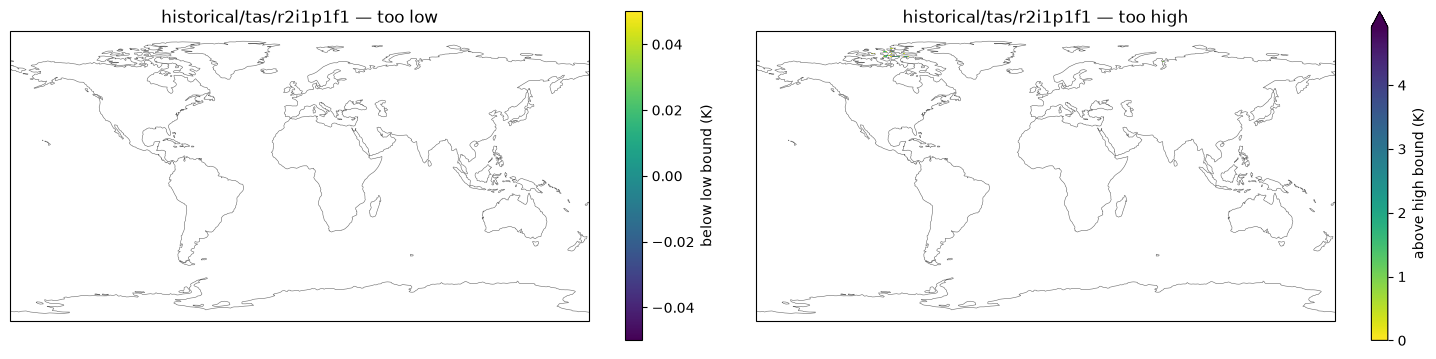

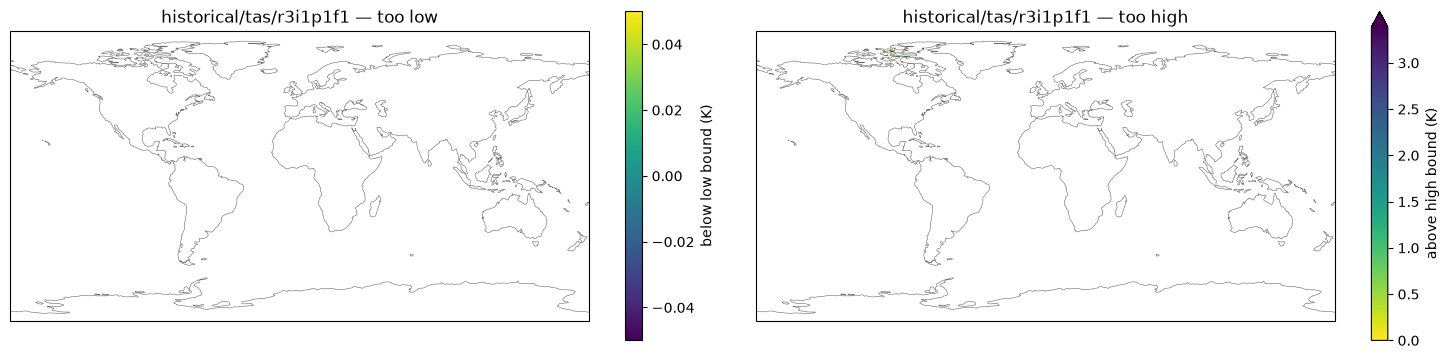

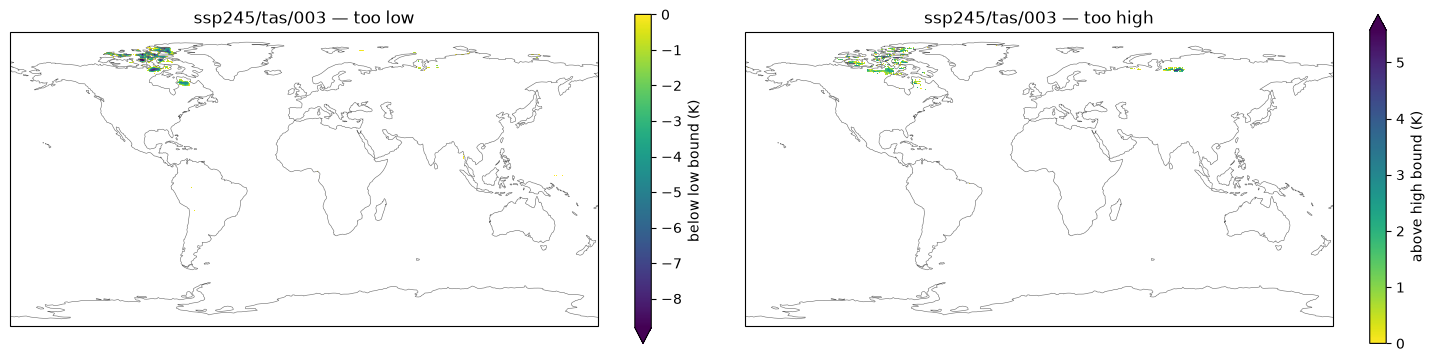

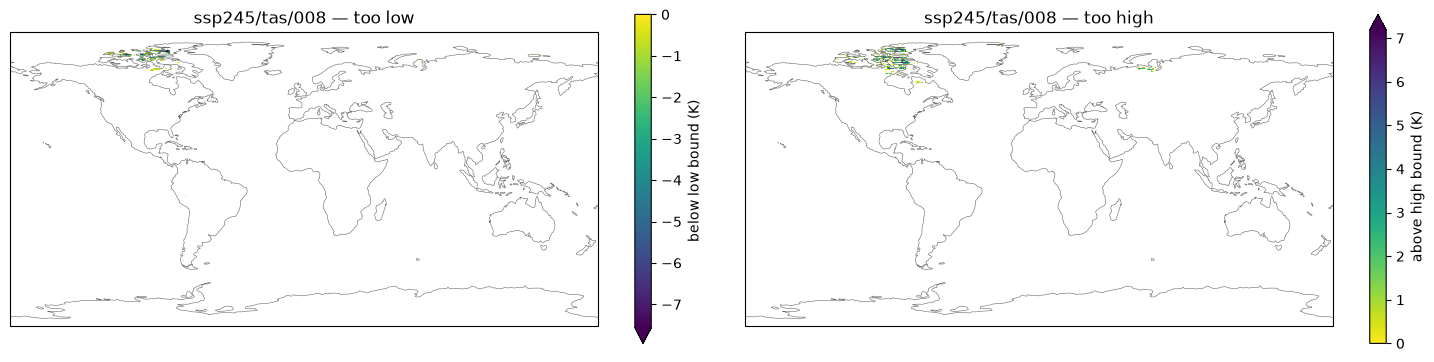

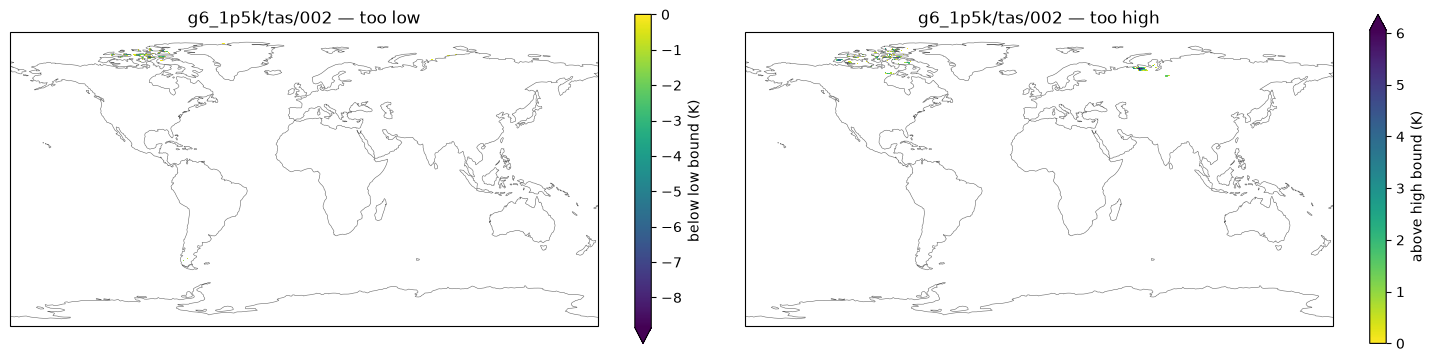

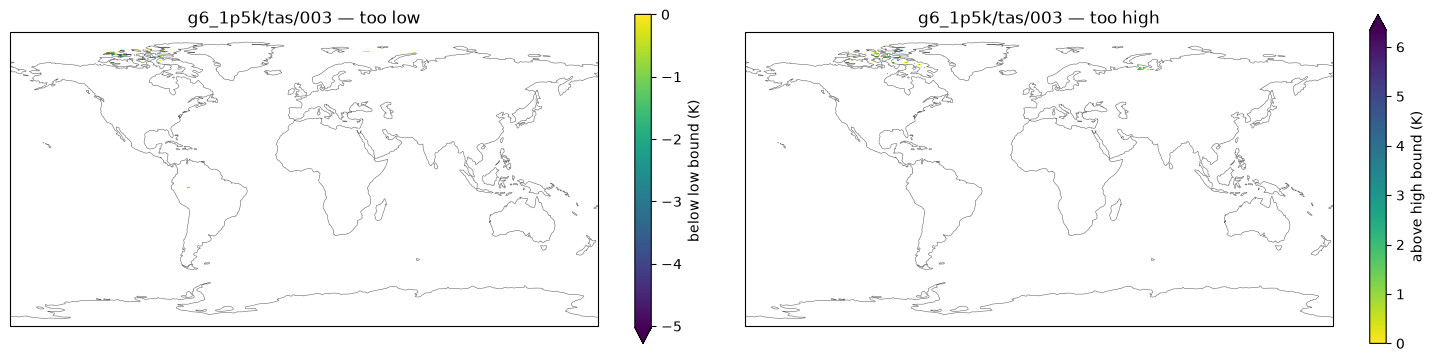

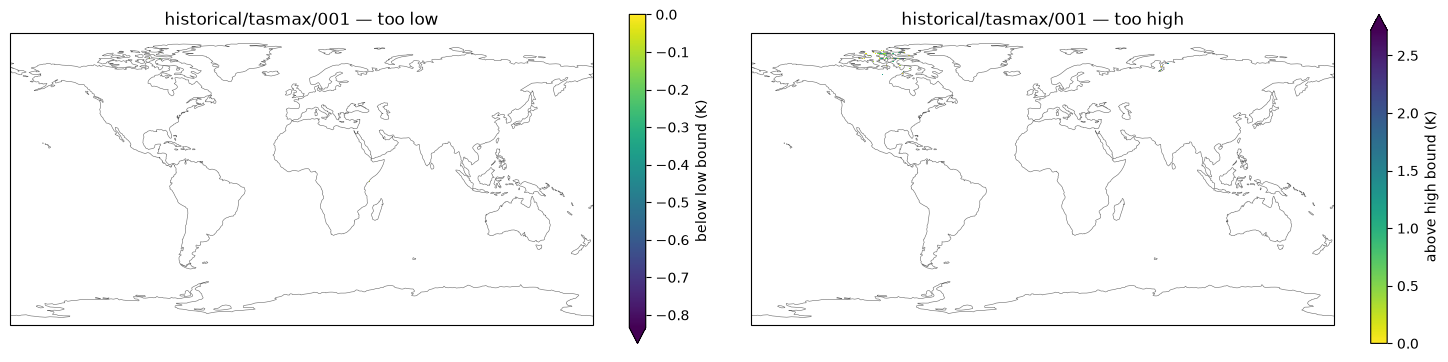

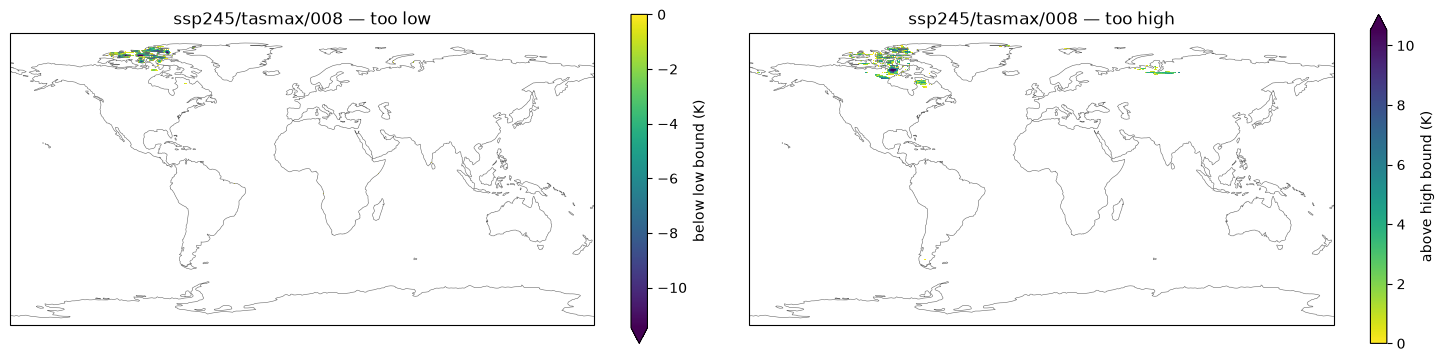

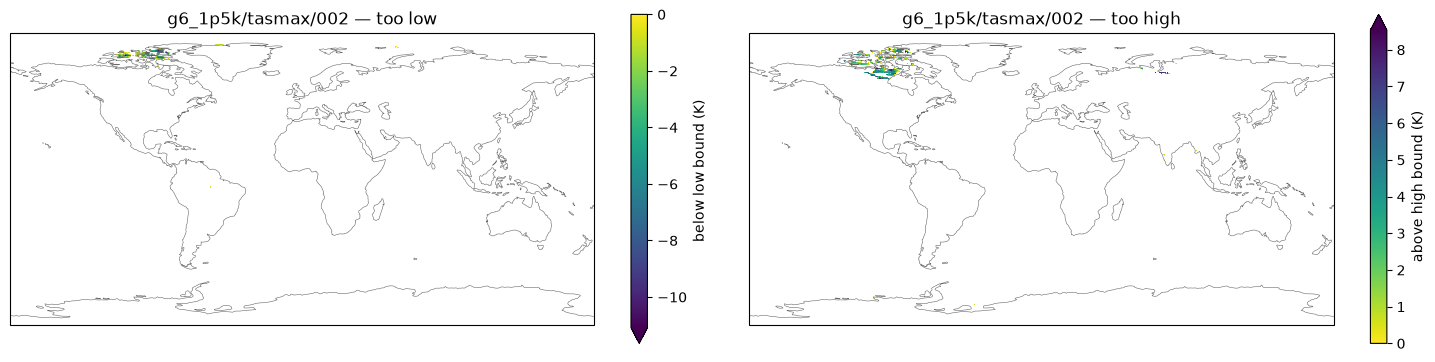

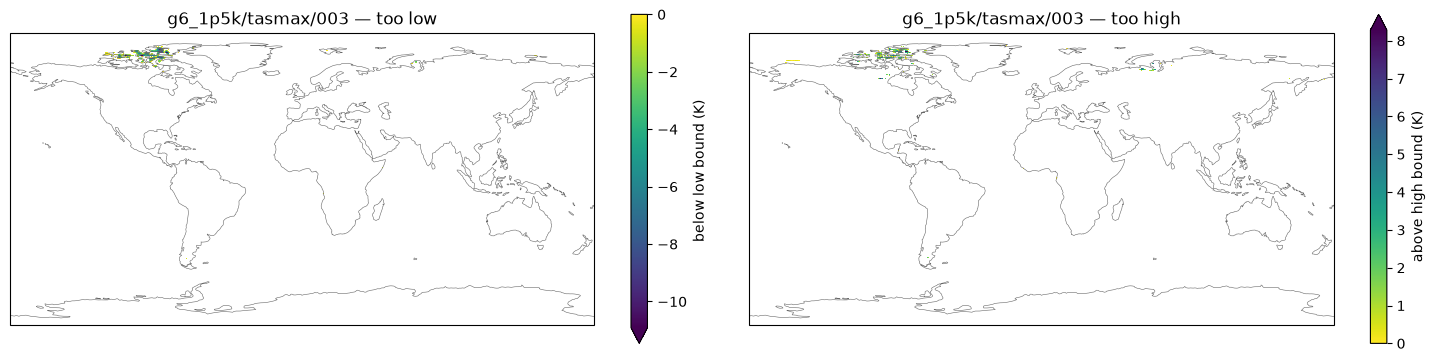

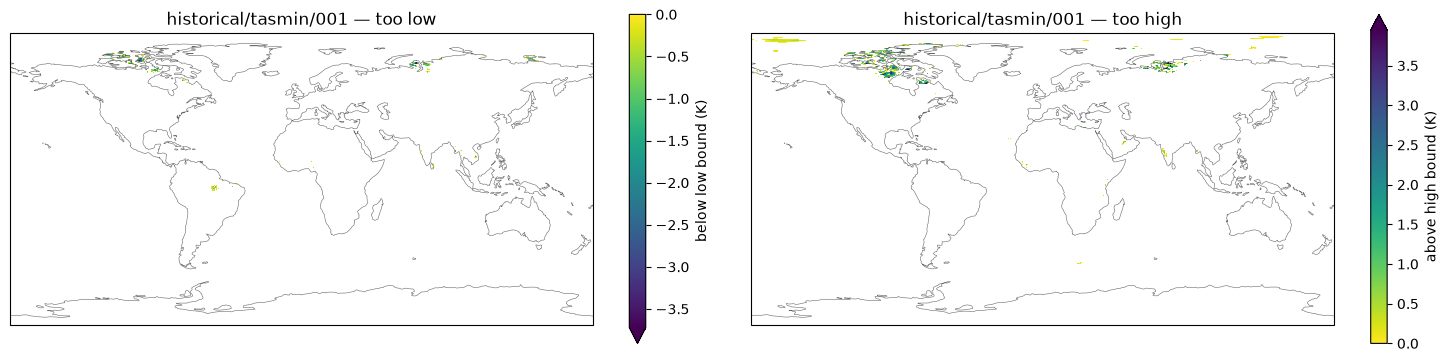

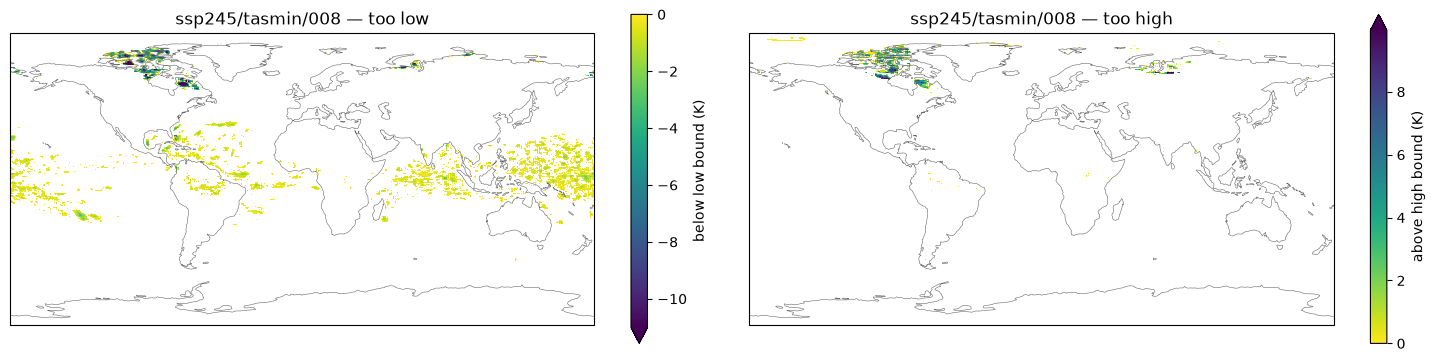

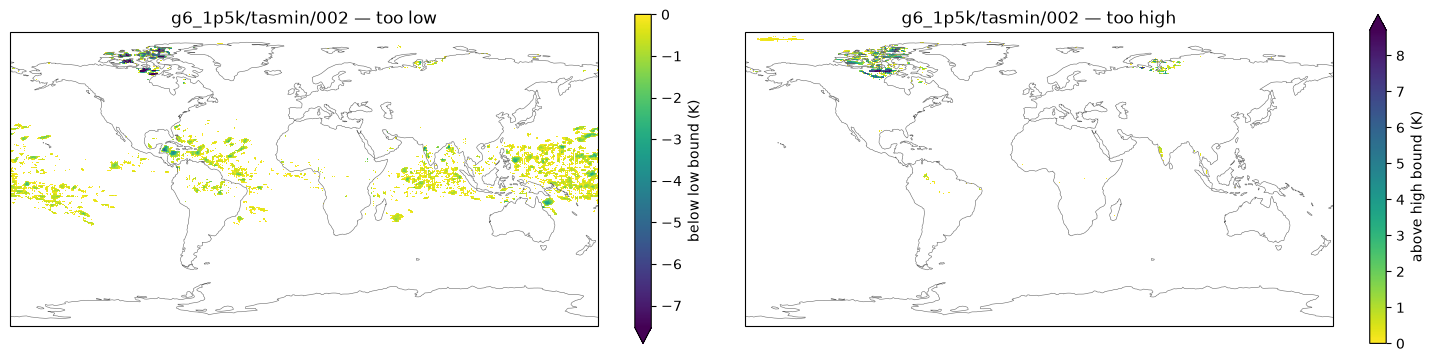

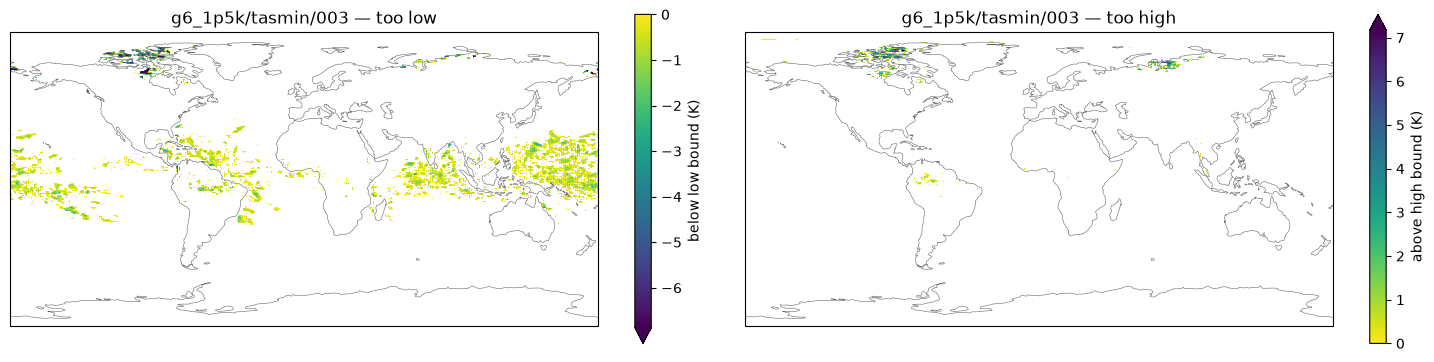

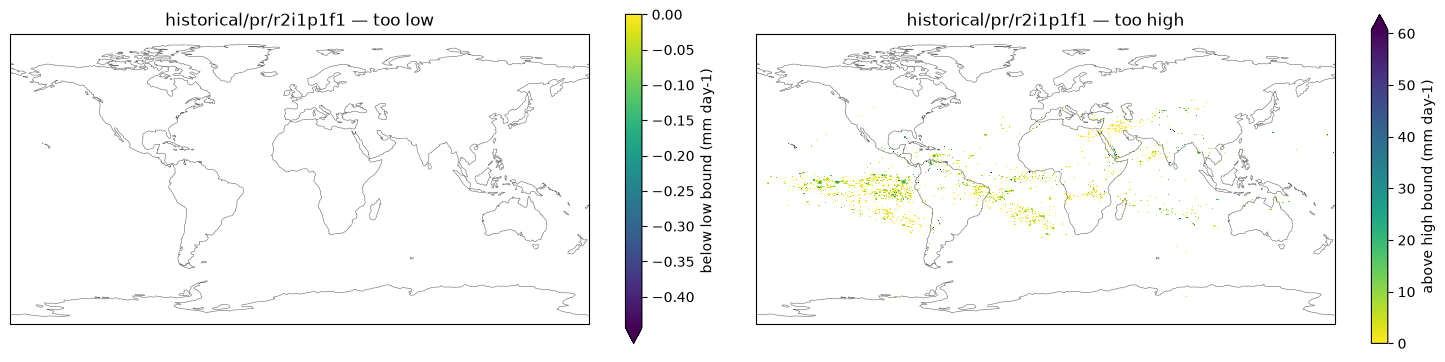

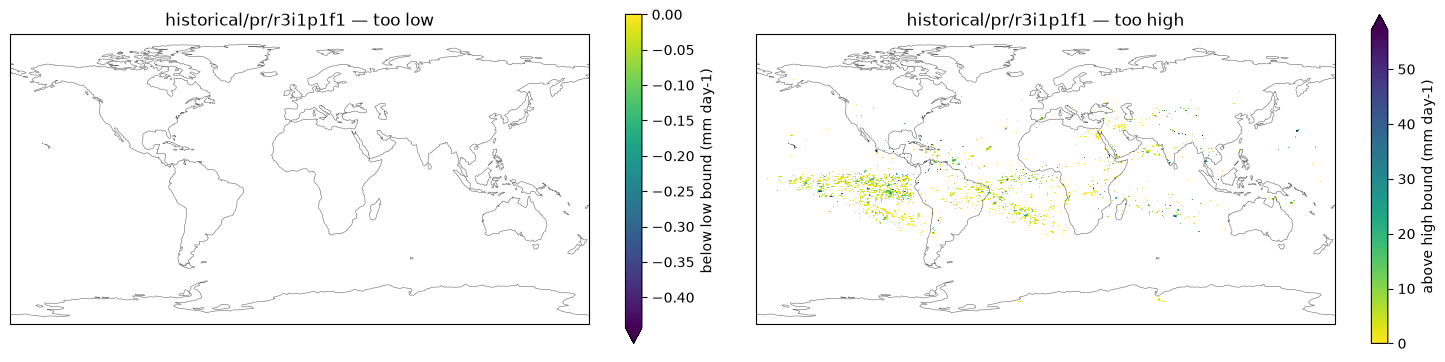

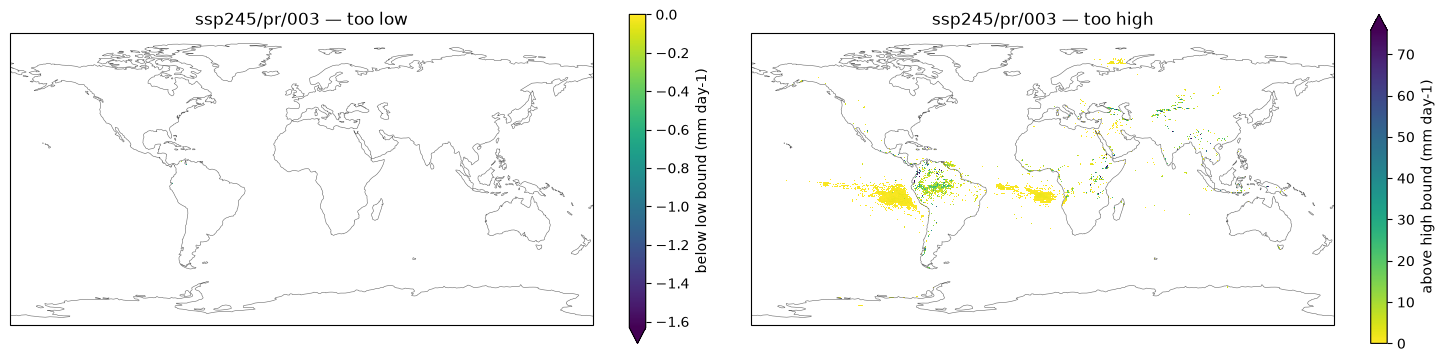

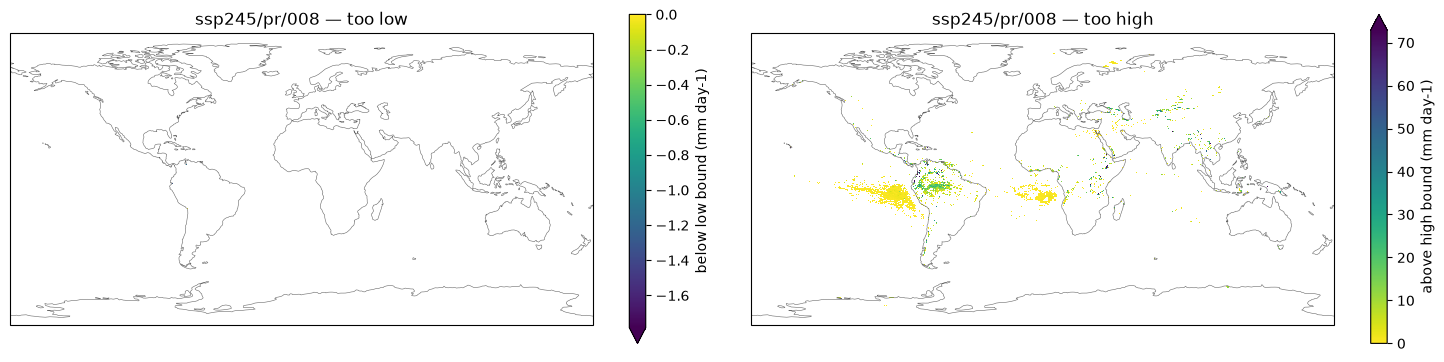

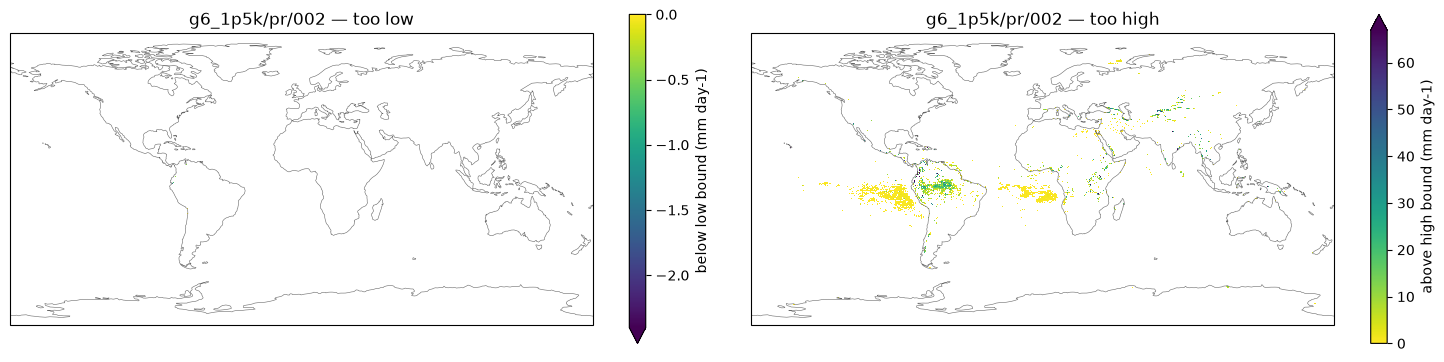

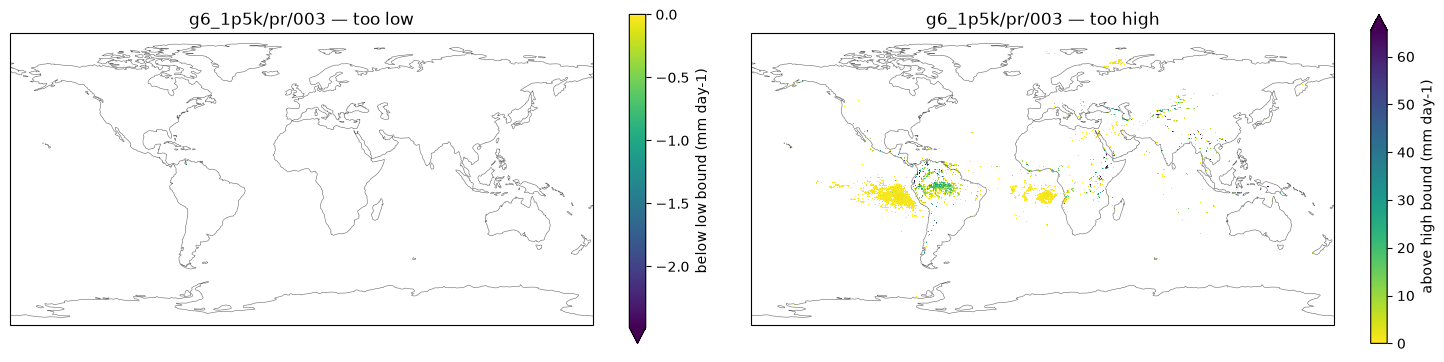

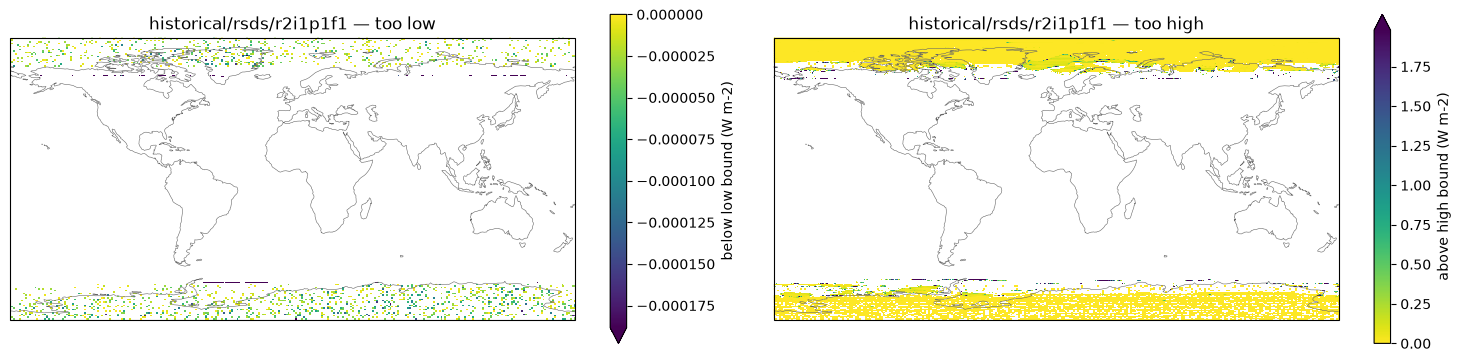

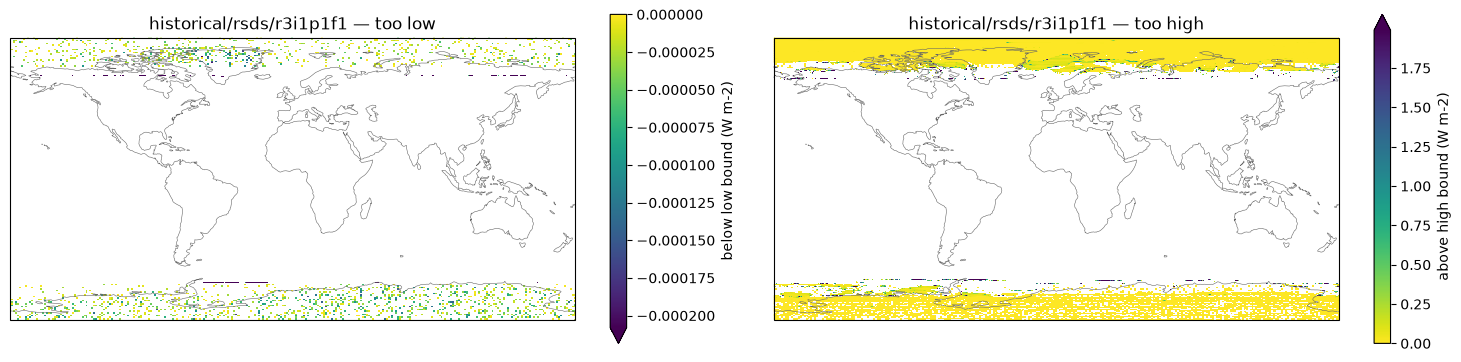

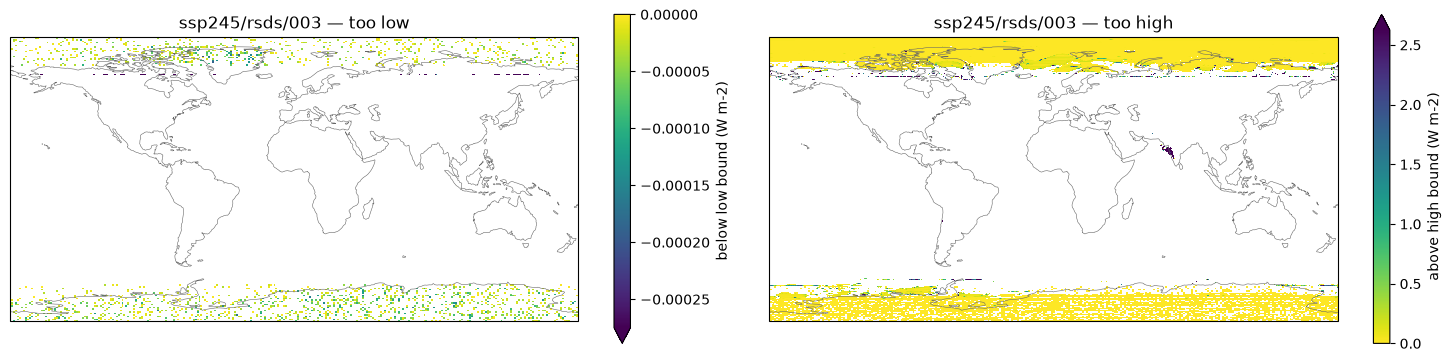

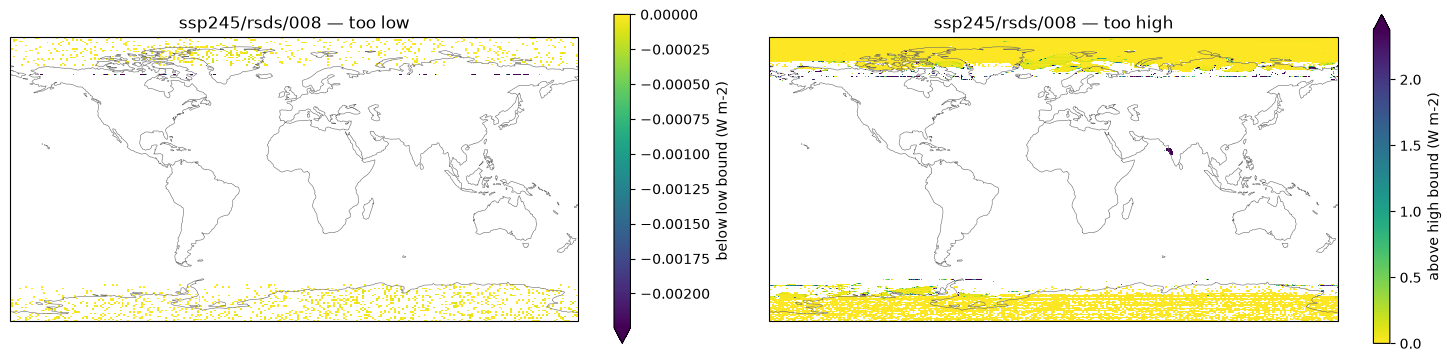

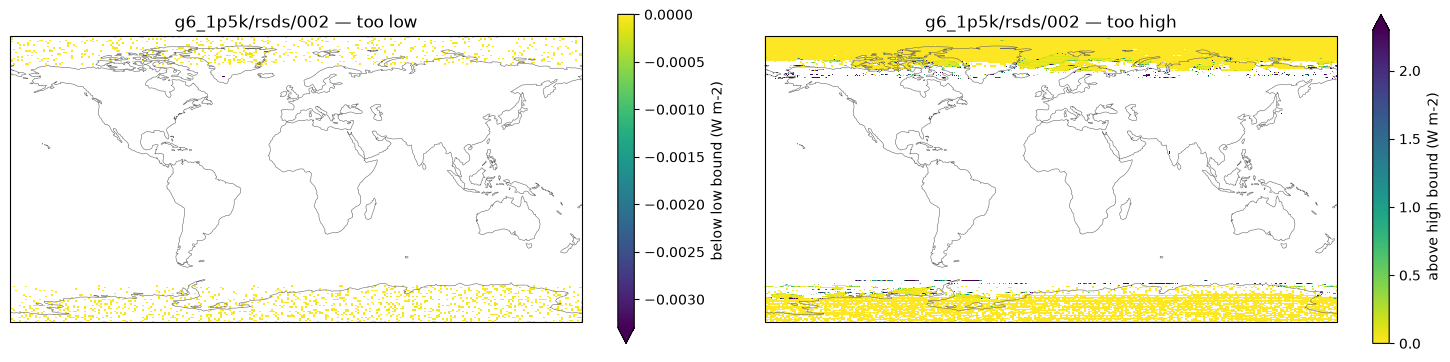

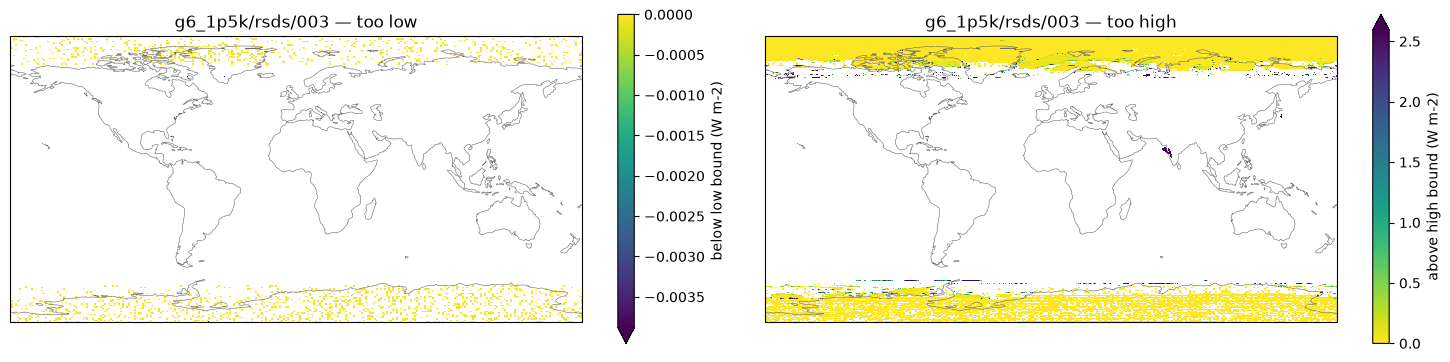

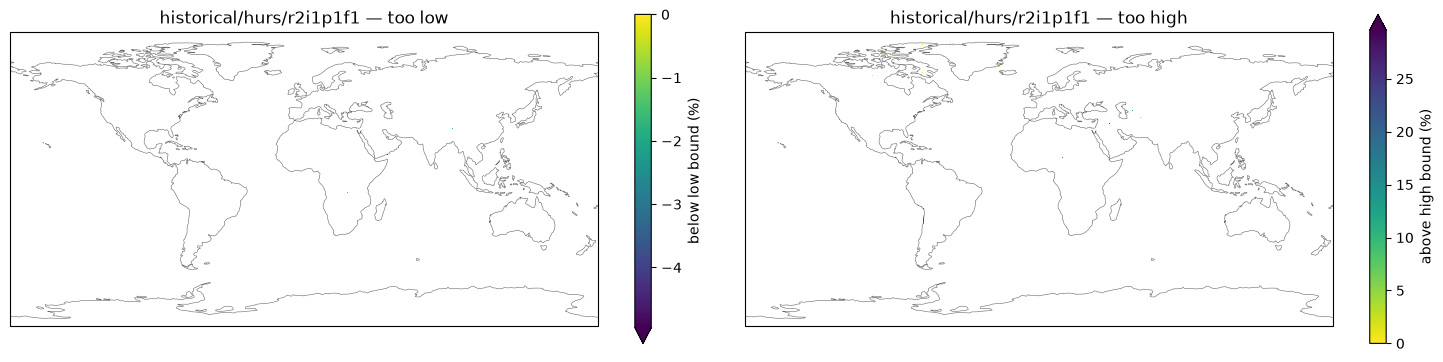

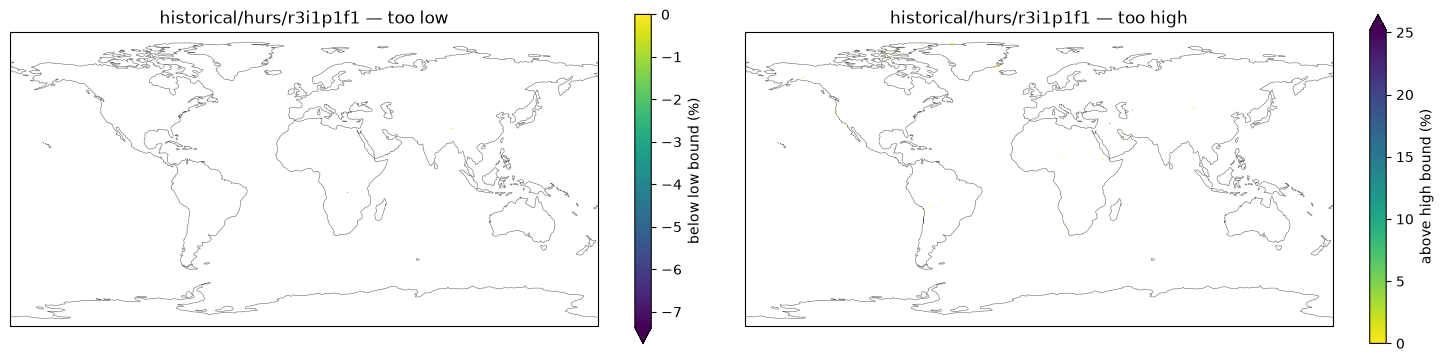

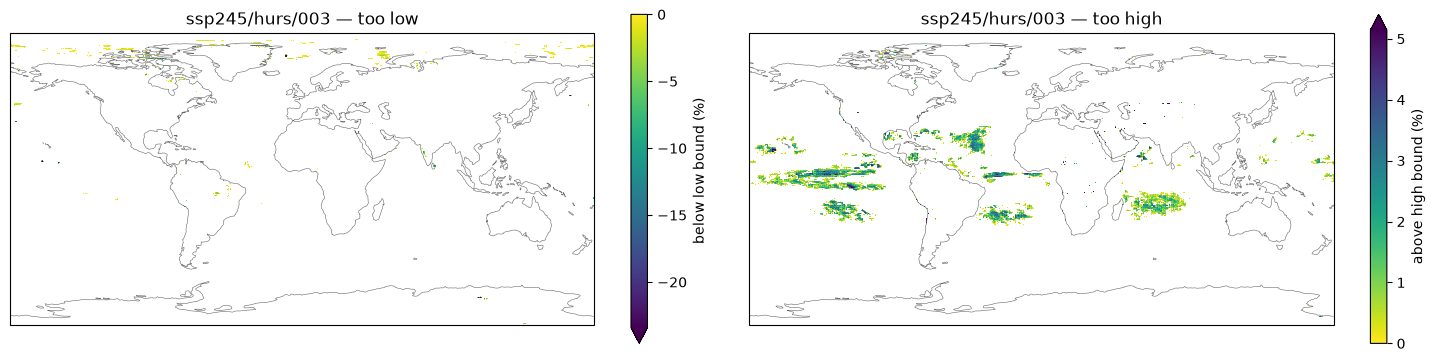

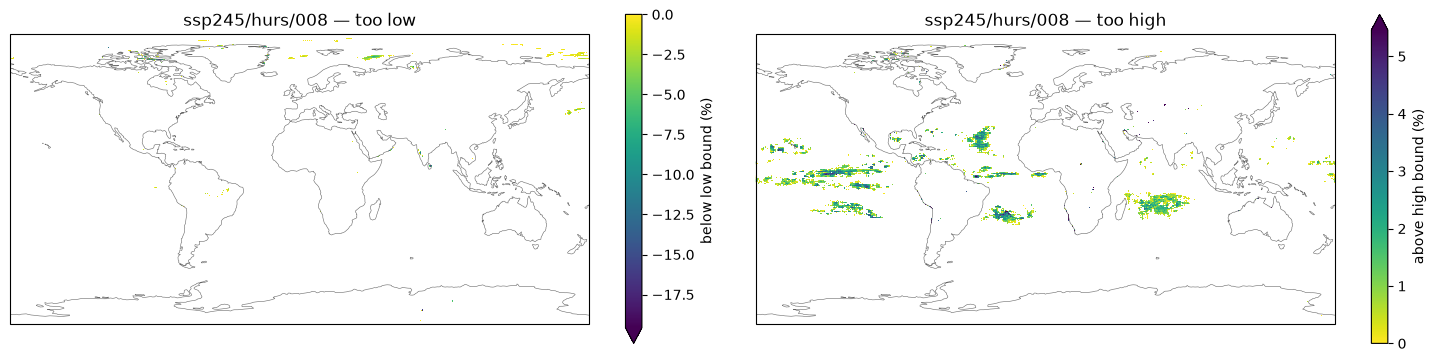

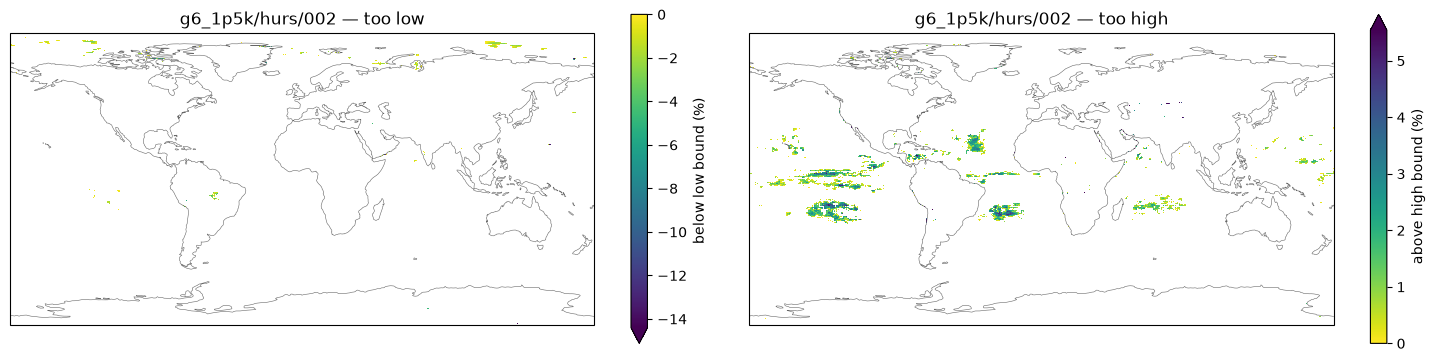

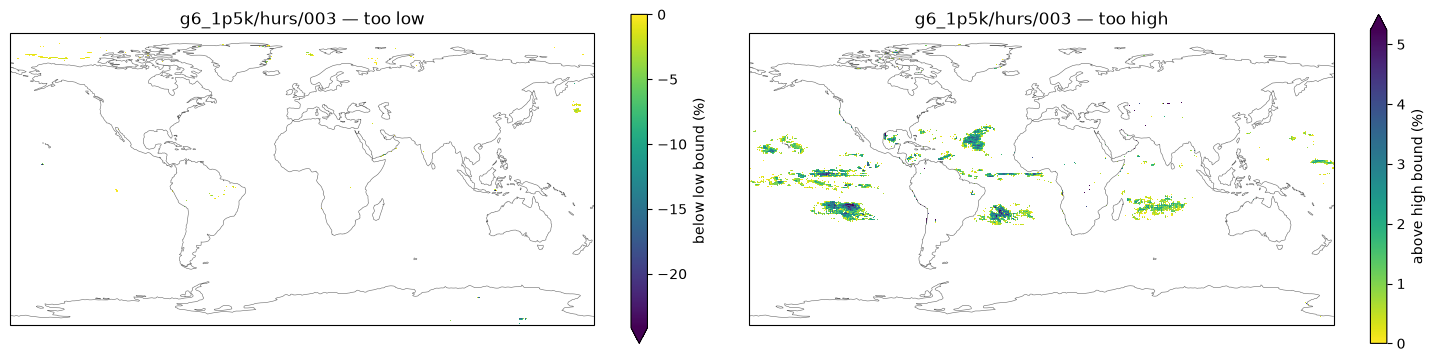

In [10]:
plot_exceedance_maps(stats)

### Drill-down helpers

Two sections below inspect individual grid cells: the deep dive, from the cached envelope, and Part 2,
from an envelope rebuilt in the current kernel. They share the functions defined here so the figures
and the flagging logic stay identical regardless of where the bounds came from. These functions now live in `srm.plotting`.

| Function | Purpose |
|---|---|
| `plot_region_zoom` | one zoomed map per ranked region, with a cross on the worst cell |
| `point_series` | every series for one grid cell, built **lazily** so many points fuse into one compute |
| `plot_point_panels` | the four-panel figure for one point, from already-computed series |

`point_series` returning lazy arrays is the point of the split. Resolving one point with seven
separate `.compute()` calls costs seven scheduler round-trips with the workers idle in between;
collecting the lazy dicts and calling `dask.compute` once lets every read for every point overlap.

In [11]:
from srm.plotting import plot_point_panels, plot_region_zoom, point_series

## Single-leaf deep dive

Part 1 answers whether any leaf is flagged. This section answers the follow-up question: for one
leaf, where are the flagged cells, and what does the record look like at a few of them. It reads the
artifact cache that Part 1 wrote instead of recomputing anything, so it runs in seconds and needs no
cluster.

The cache is what makes this cheap, not the single-leaf filter. Narrowing the check to one leaf
removes only the per-leaf reduction; the observed envelope is per *variable* and is paid in full no
matter how many leaves you ask for.

| Ingredient | Scope | Approx. read | Removed by picking one leaf? |
|---|---|---|---|
| Observed day-of-year envelope | per variable | ~70 GB | No |
| Downscaled leaf day-of-year reduction | per leaf | ~90 GB | Only for the other leaves |

A single-leaf recompute therefore costs roughly 40 % of the four-leaf batch, not 25 % of it, and
`functools.cache` on `obs_bounds_cached` does not change that: it memoizes the lazy graph, so it
dedupes within one `dask.compute` and carries nothing across a kernel restart. Only persisting the
computed values does.

The cheap half is still recomputed here. `leaf_bounds` adds the coarse-grid scenario delta to the
cached observed envelope, so the deep dive compares against exactly the bound Part 1 used, clamp
included, without storing a separate copy per leaf.

**To run this section on its own**, just run every cell from the top with `COMPUTE_MODE` left at
`auto`. Once the cache is populated, `auto` resolves to `cached`, no cluster is created, and "Running
the check" loads the committed leaf maps instead of recomputing them, so the whole notebook reaches
this section in seconds. There are no cells to skip and no ordering to remember, which matters because
a forgotten skip used to mean 30 VMs and a multi-hour reduction.

In [12]:
# Set the leaf and how much of it to inspect, then run this section on its own.
DEEP_DIVE_SCENARIO = "historical"
DEEP_DIVE_VAR = "pr"
DEEP_DIVE_MEMBER = "r3i1p1f1"

N_REGIONS = 6  # coherent regions to rank, zoom into, and pick drill-down points from
MIN_REGION_CELLS = 4  # drop components smaller than this: the isolated coastline / sea-ice flecks
N_POINTS = 3  # points to resolve in one compute, taken from the worst cell of the top regions

deep_dive_key = (DEEP_DIVE_SCENARIO, DEEP_DIVE_VAR, DEEP_DIVE_MEMBER)
if deep_dive_key not in leaves:
    raise KeyError(
        f"{'/'.join(deep_dive_key)} not found among discovered leaves -- see the leaf list above"
    )
deep_dive_units, deep_dive_scale = display_units(DEEP_DIVE_VAR)

# Both reads come from the cache Part 1 wrote: a few MB of exceedance maps, and an envelope left
# lazy so a single-point selection later fetches one chunk instead of the whole ~3 GB.
deep_dive_stats = load_exceedance_maps(keys=[deep_dive_key])
deep_dive_map = deep_dive_stats[deep_dive_key]
deep_dive_low, deep_dive_high = leaf_bounds(deep_dive_key, *load_doy_envelope(DEEP_DIVE_VAR))

print(f"{'/'.join(deep_dive_key)}  (cache: {CACHE_STORE_URI}, branch {BRANCH})")
print(
    f"  too high: {float(deep_dive_map.frac_area_too_high):.5%} of area, worst "
    f"{float(deep_dive_map.diff_gt_doy_max) * deep_dive_scale:.3f} {deep_dive_units}"
)
print(
    f"  too low:  {float(deep_dive_map.frac_area_too_low):.5%} of area, worst "
    f"{float(deep_dive_map.diff_lt_doy_min) * deep_dive_scale:.3f} {deep_dive_units}"
)

historical/pr/r3i1p1f1  (cache: s3://carbonplan-scratch/srm/qaqc/CESM2-WACCM-ERA5-global.icechunk, branch v0.13.0)
  too high: 1.39197% of area, worst 861.163 mm day-1
  too low:  0.00019% of area, worst -0.447 mm day-1


In [13]:
# Connected components of the flagged mask, ranked by exceedance magnitude. `n_cells` is what
# separates a coherent patch worth investigating from an isolated fleck, and `min_cells` drops the
# flecks outright. Components touching across the antimeridian are merged into one region; for those
# the lon_min/lon_max box is meaningless, which `wraps_lon` flags.
regions_high = find_exceedance_regions(
    deep_dive_map.over,
    direction="high",
    min_cells=MIN_REGION_CELLS,
    top_n=N_REGIONS,
    scale=deep_dive_scale,
)
regions_low = find_exceedance_regions(
    deep_dive_map.under,
    direction="low",
    min_cells=MIN_REGION_CELLS,
    top_n=N_REGIONS,
    scale=deep_dive_scale,
)

for label, regions in [
    ("above the high bound", regions_high),
    ("below the low bound", regions_low),
]:
    print(f"Top {N_REGIONS} regions {label}, magnitudes in {deep_dive_units}:")
    print(regions.to_string(index=False) if len(regions) else "  none")
    print()

Top 6 regions above the high bound, magnitudes in mm day-1:
 region  n_cells  area_frac  worst_value  worst_lat  worst_lon  centroid_lat  centroid_lon  lat_min  lat_max  lon_min  lon_max  wraps_lon
      1        8   0.000008   861.163464      19.50    -155.75     19.625000   -155.875000    19.25    20.00  -156.00  -155.75      False
      2        7   0.000007   265.338875      27.75      87.25     27.642857     87.107144    27.50    28.00    86.50    87.50      False
      3        9   0.000009   236.588819      17.00     -94.50     17.138889    -94.166667    17.00    17.25   -94.75   -93.50      False
      4       22   0.000021   198.309284      10.75     -74.00     10.568182    -74.750001    10.00    11.00   -75.50   -74.00      False
      5        6   0.000006   171.332404      29.25      80.00     29.375000     80.000000    29.25    29.50    79.75    80.25      False
      6        6   0.000006   165.185465      19.75     -72.50     19.791667    -72.500000    19.50    20.00   -

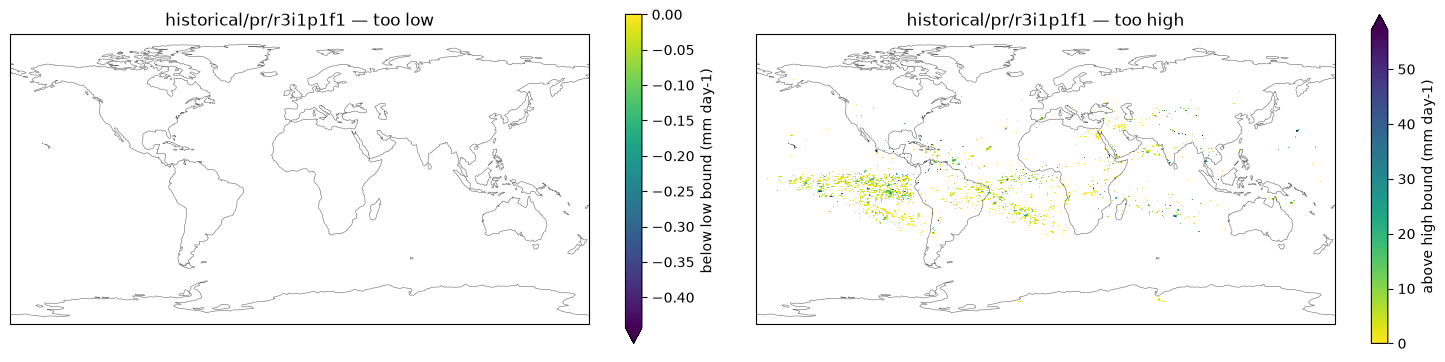

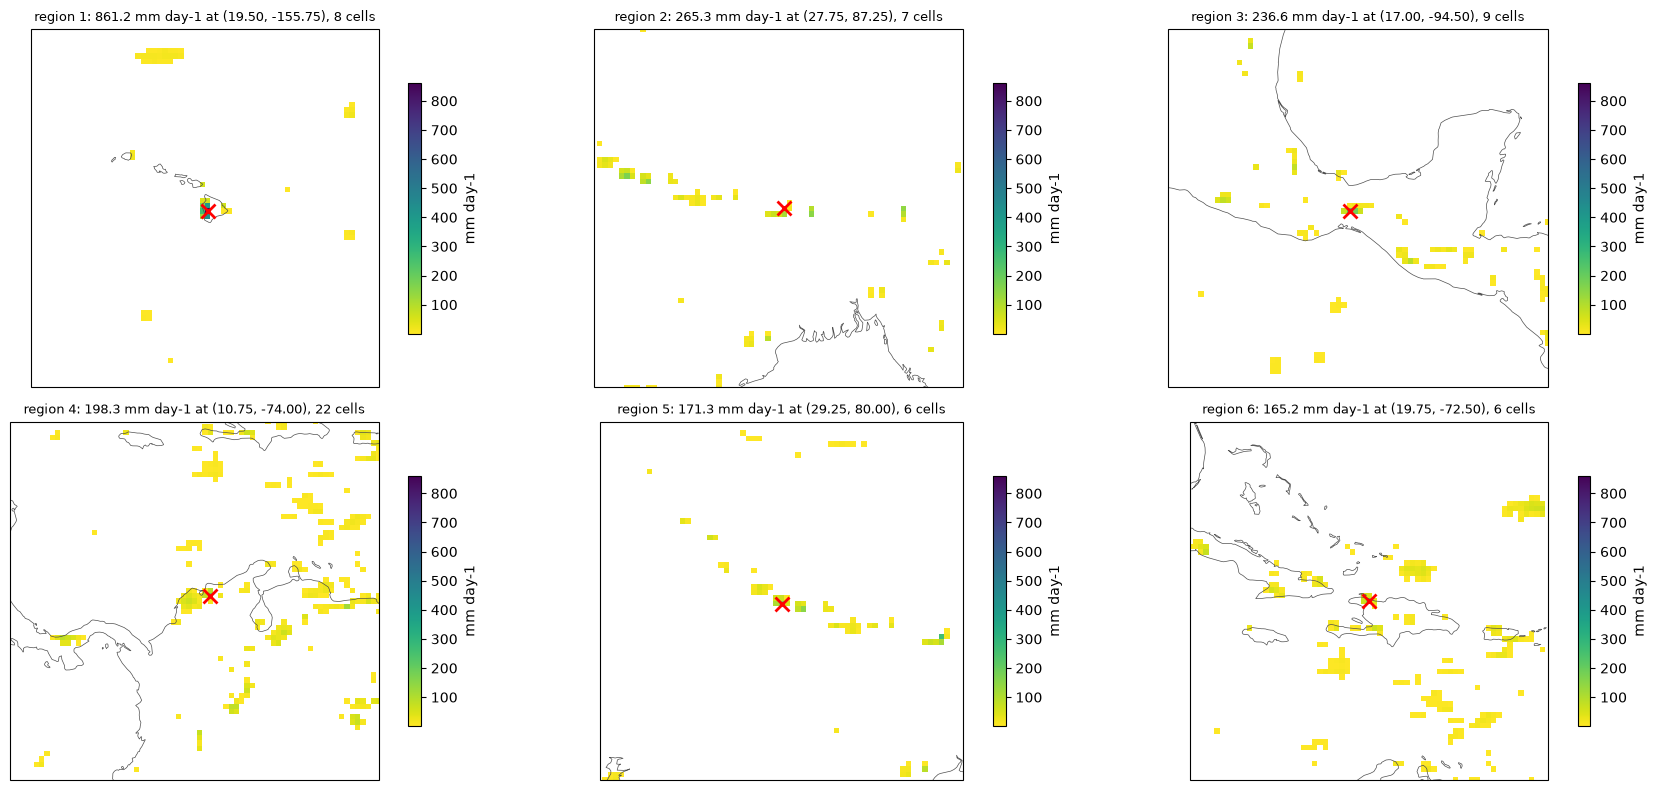

no low regions to plot


In [14]:
# The global pair for context, then a zoom per ranked region with a cross on its worst cell.
plot_exceedance_maps(deep_dive_stats)
plot_region_zoom(
    deep_dive_map.over,
    regions_high,
    direction="high",
    units=deep_dive_units,
    scale=deep_dive_scale,
)
plot_region_zoom(
    deep_dive_map.under,
    regions_low,
    direction="low",
    units=deep_dive_units,
    scale=deep_dive_scale,
)

### Example points in the flagged regions

The worst cell of each top-ranked region becomes a drill-down point. Every series for every point is
built lazily and evaluated in one `dask.compute`, so the reads overlap rather than queueing: the same
work issued as separate `.compute()` calls per point costs a scheduler round-trip each with the
workers idle in between. Switch `deep_dive_regions` to `regions_low` to inspect the lower bound
instead.

Resolved 3 point(s) in one compute



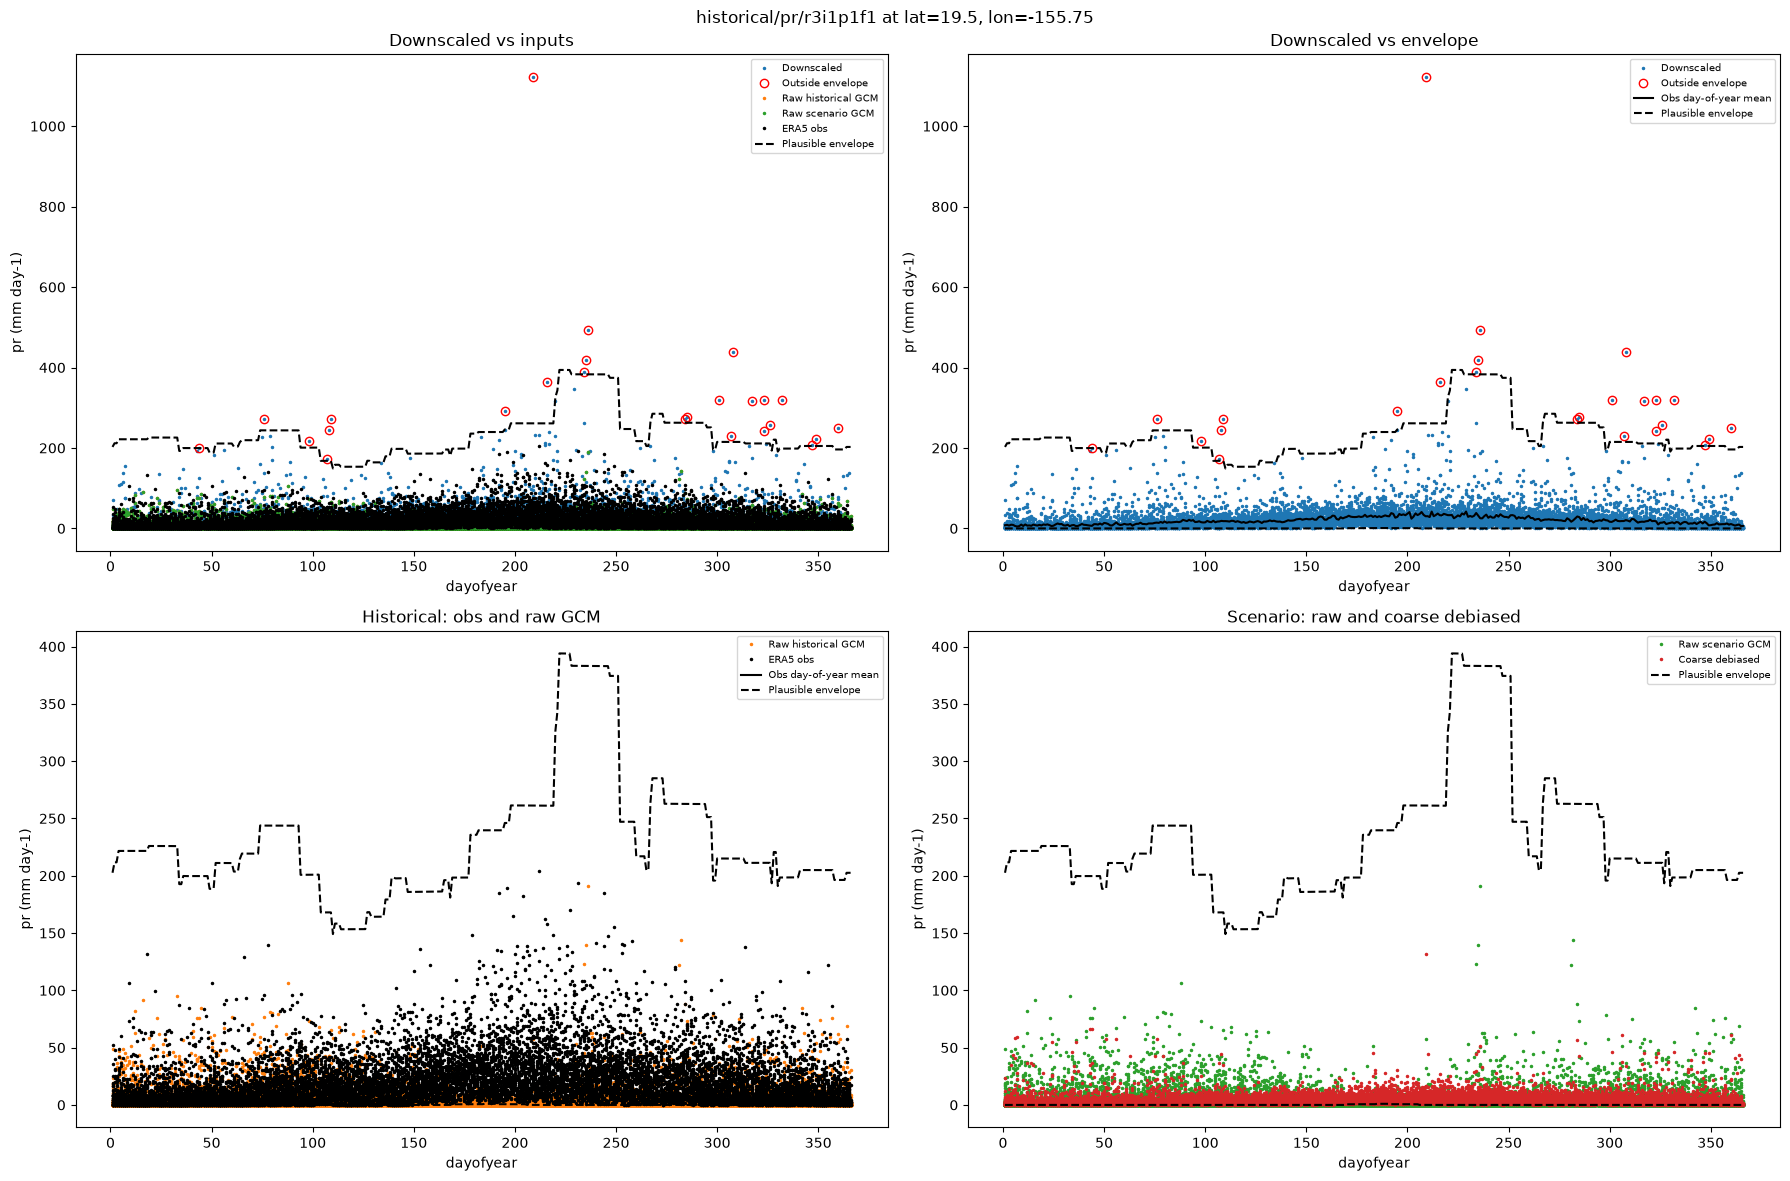

(19.50, -155.75): 25 of 13514 days outside the envelope


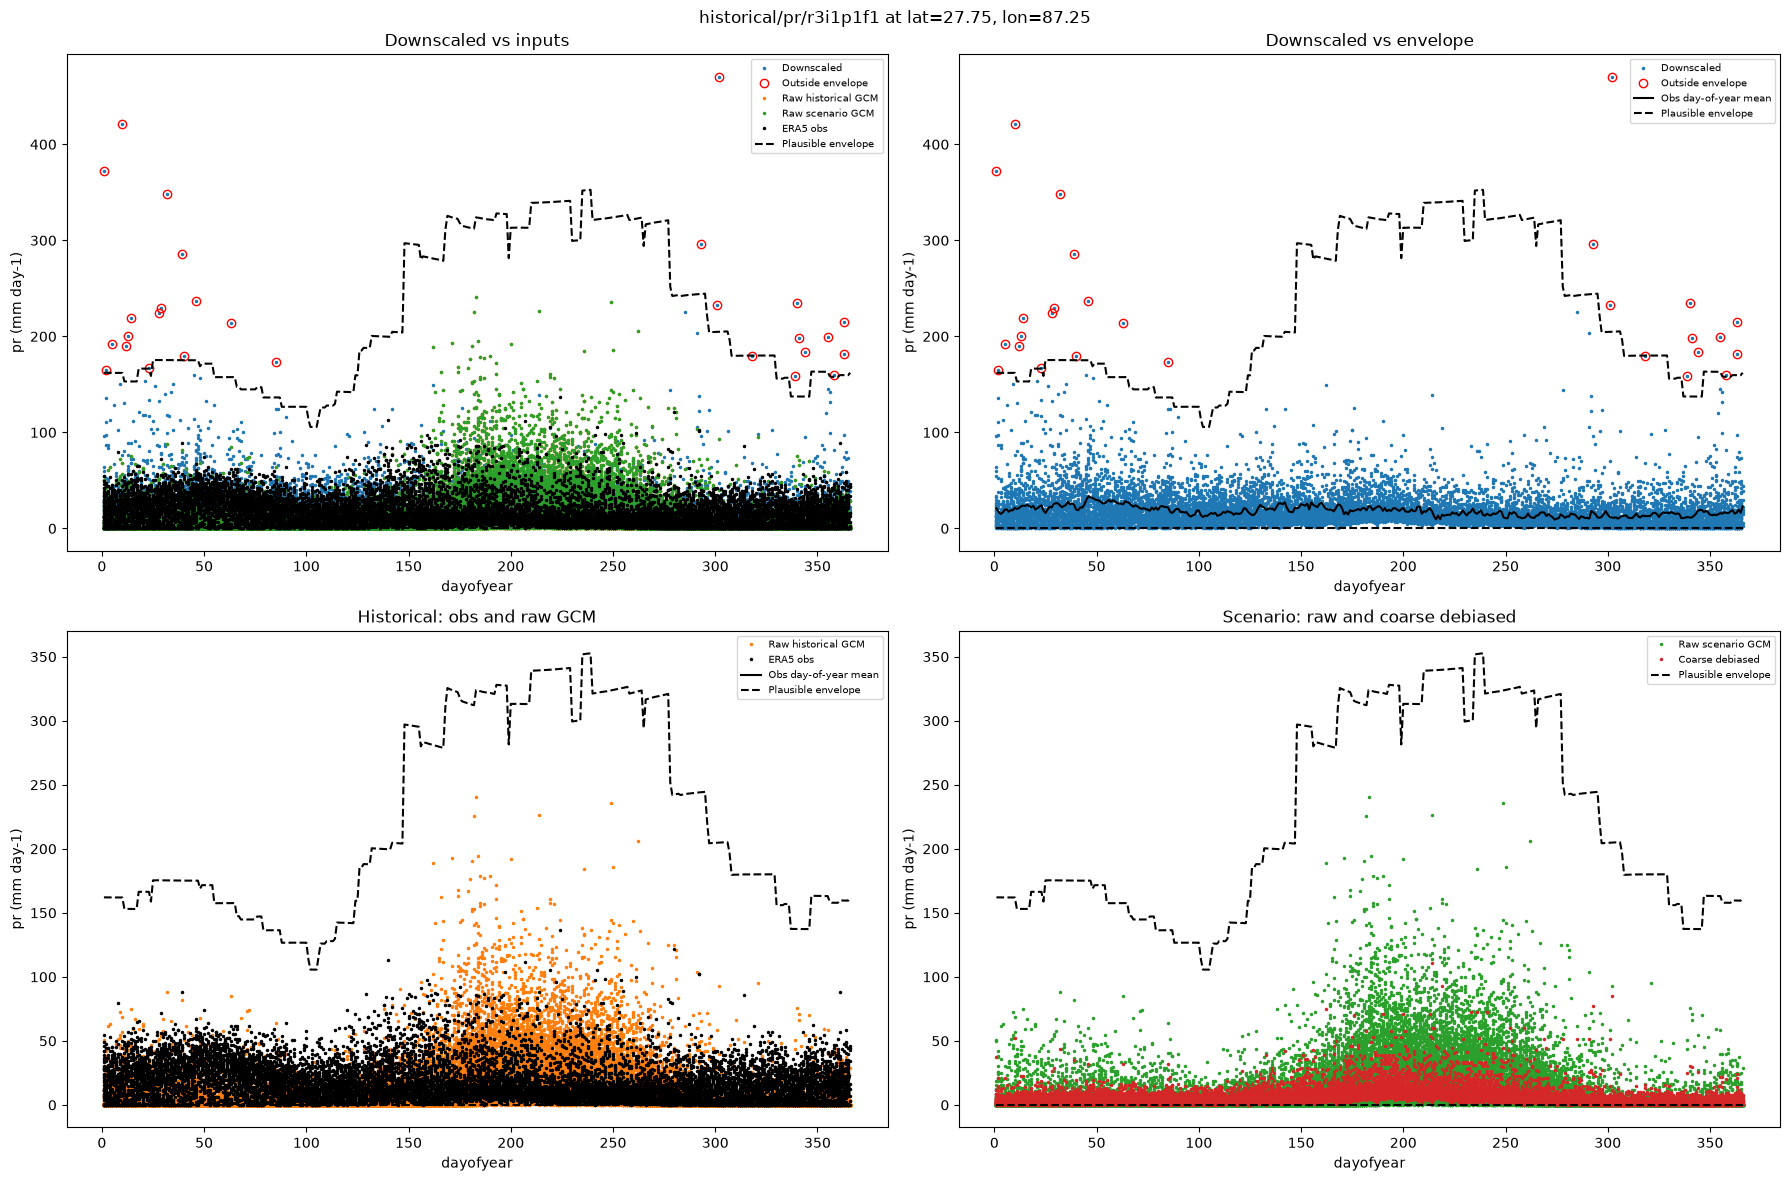

(27.75, 87.25): 28 of 13514 days outside the envelope


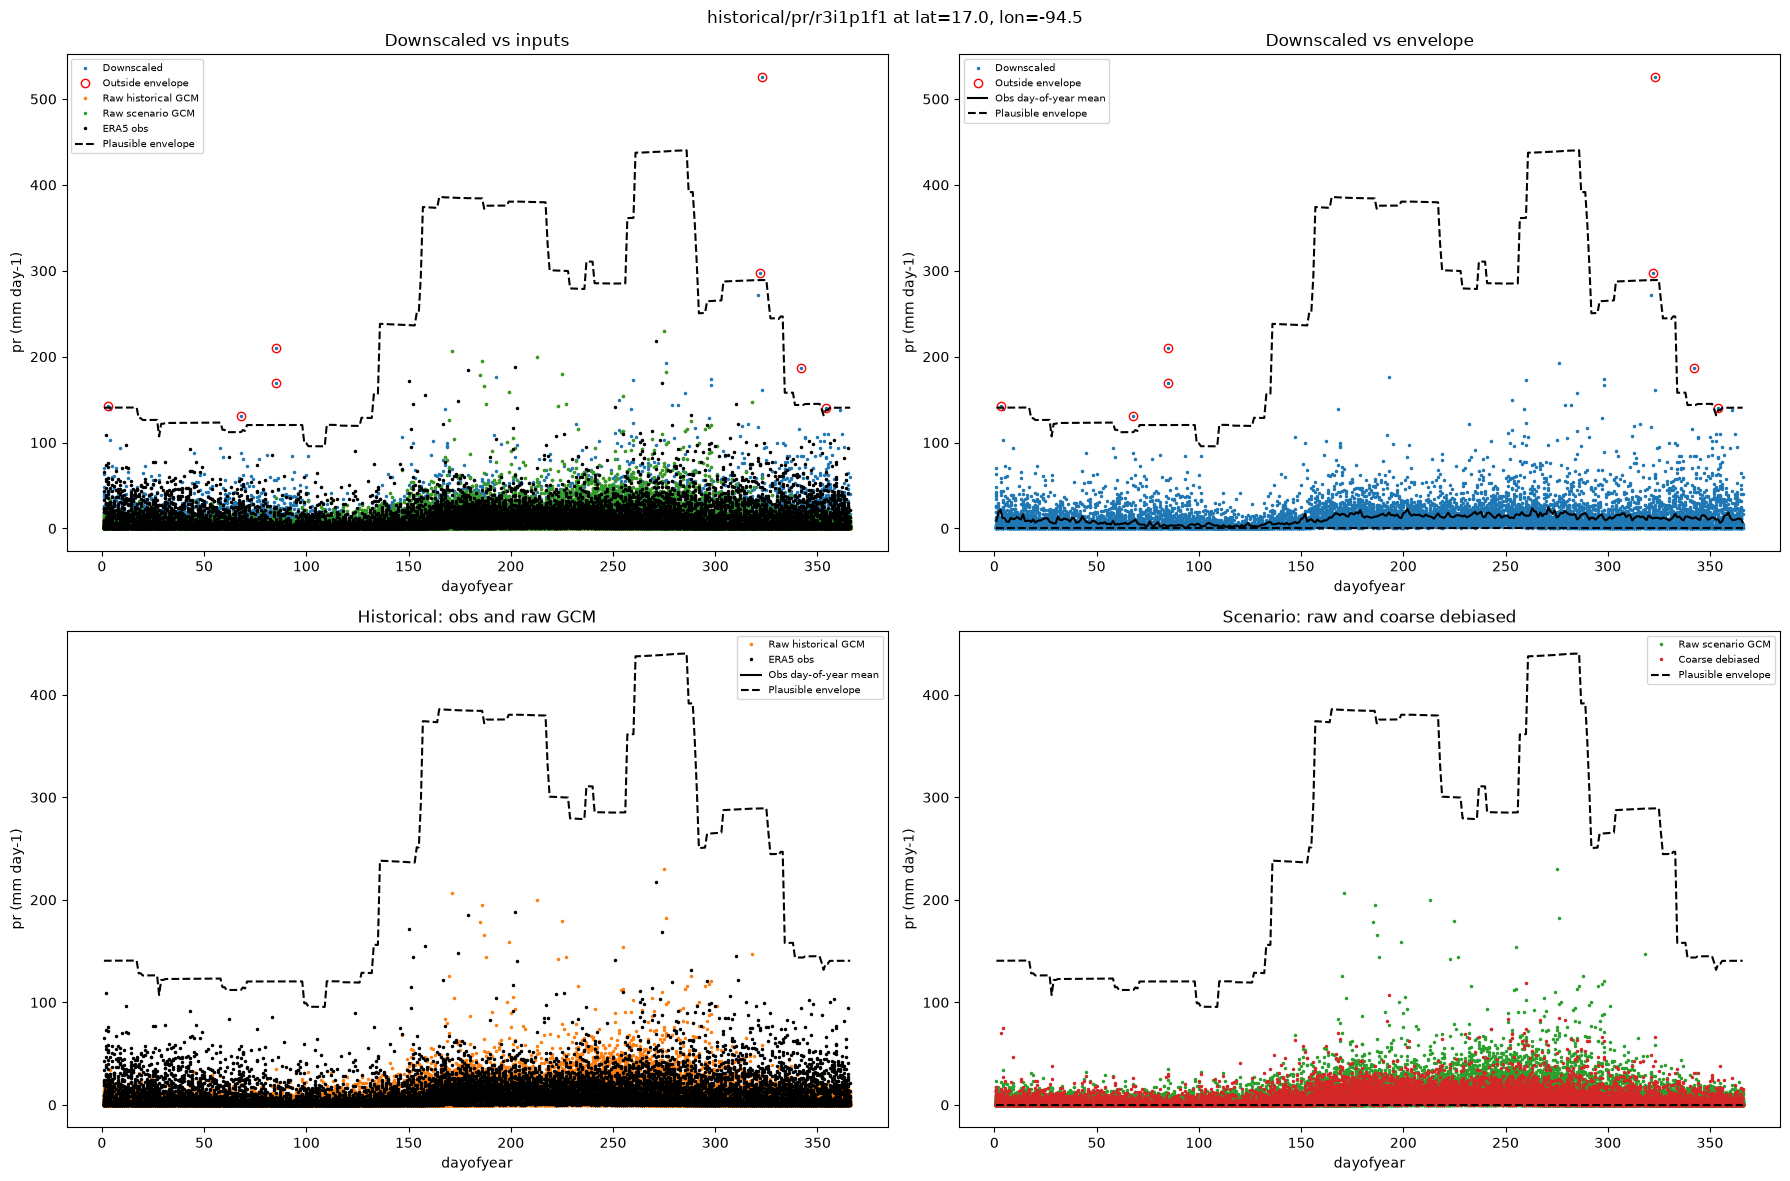

(17.00, -94.50): 8 of 13514 days outside the envelope
CPU times: user 2.45 s, sys: 80.2 ms, total: 2.53 s
Wall time: 20 s


In [15]:
%%time
deep_dive_regions = regions_high  # or regions_low, to inspect the lower bound instead

deep_dive_points = [
    (region.worst_lat, region.worst_lon) for region in deep_dive_regions.head(N_POINTS).itertuples()
]
if not deep_dive_points:
    raise ValueError(
        "no regions survived MIN_REGION_CELLS -- lower it, or switch deep_dive_regions"
    )

# One graph for every point and every series. The bounds come from the cached envelope, so nothing
# here re-reduces the observation record.
lazy = {
    point: point_series(
        deep_dive_key,
        *point,
        deep_dive_low,
        deep_dive_high,
        tree=tree,
        leaves=leaves,
        obs_fine=obs_fine,
        gcm=CESM,
        historical_member=historical_member,
    )
    for point in deep_dive_points
}
(deep_dive_series,) = dask.compute(lazy)
print(f"Resolved {len(deep_dive_series)} point(s) in one compute\n")

for (point_lat, point_lon), series in deep_dive_series.items():
    n_flagged = plot_point_panels(
        series,
        deep_dive_key,
        point_lat,
        point_lon,
        units=deep_dive_units,
        scale=deep_dive_scale,
    )
    n_days = series["downscaled"].sizes["time"]
    print(f"({point_lat:.2f}, {point_lon:.2f}): {n_flagged} of {n_days} days outside the envelope")

## Part 2 — single-point drill-down

A map tells you *where* a leaf leaves the envelope; to understand *why*, it helps to look at one
grid cell across the whole record. Below we pick one flagged leaf and one point and plot the
downscaled daily values against the plausible envelope and the underlying inputs (raw scenario GCM,
raw historical GCM, ERA5 observations, and the coarse debiased output). Change `drill_key` and the
point to inspect any cell; the defaults below inspect a flagged `rsds` leaf. Every series in the
figure is converted to the leaf's reporting units before plotting, so an `rsds` drill-down reads in
W m⁻² on the same scale as the summary table above.

This section rebuilds the envelope in the current kernel, so it requires "Running the check" above to have been run and a cluster to be up. The deep dive is the cheaper route to the same figure for a leaf whose artifacts are already cached; this one stays useful when the batch is already in memory and you want a leaf chosen from the full summary.

In [16]:
# Pick a leaf to inspect more closely (one that was flagged). This reads `stats` and `summary`
# from the full Part 1 run; it does not use the deep-dive cache.
_preferred = ("ssp245", "pr", "003")

In [17]:
ilat, ilon = 3.5, -77.3  # example point (store coordinate convention)

In [18]:
# Default to a known flagged leaf if present, else the first flagged leaf, else the first leaf.
if _preferred in stats:
    drill_key = _preferred
else:
    _flagged = summary.index[~summary["pass"]]
    drill_key = tuple(_flagged[0]) if len(_flagged) else next(iter(stats))
drill_units, drill_scale = display_units(drill_key[1])

print(f"Drilling into {'/'.join(drill_key)} at lat={ilat}, lon={ilon}")

# Rebuild this leaf's bounds from the in-kernel observed envelope, then resolve every series for the
# point in ONE dask.compute. dask prunes the graph to the one column, but the rebuilt envelope still
# pulls a full spatial chunk through the whole observation record; the deep dive above avoids that by
# reading the committed envelope out of the cache instead.
# In a cached run there is no cluster to rebuild the envelope on, and no reason to: the committed
# copy is the same array. A full run keeps using the in-kernel envelope it already has in its graph.
_drill_obs = (
    load_doy_envelope(drill_key[1])
    if RESOLVED_MODE == "cached"
    else obs_bounds_cached(drill_key[1])
)
drill_low, drill_high = leaf_bounds(drill_key, *_drill_obs)
(drill_series,) = dask.compute(
    point_series(
        drill_key,
        ilat,
        ilon,
        drill_low,
        drill_high,
        tree=tree,
        leaves=leaves,
        obs_fine=obs_fine,
        gcm=CESM,
        historical_member=historical_member,
    )
)

Drilling into ssp245/pr/003 at lat=3.5, lon=-77.3


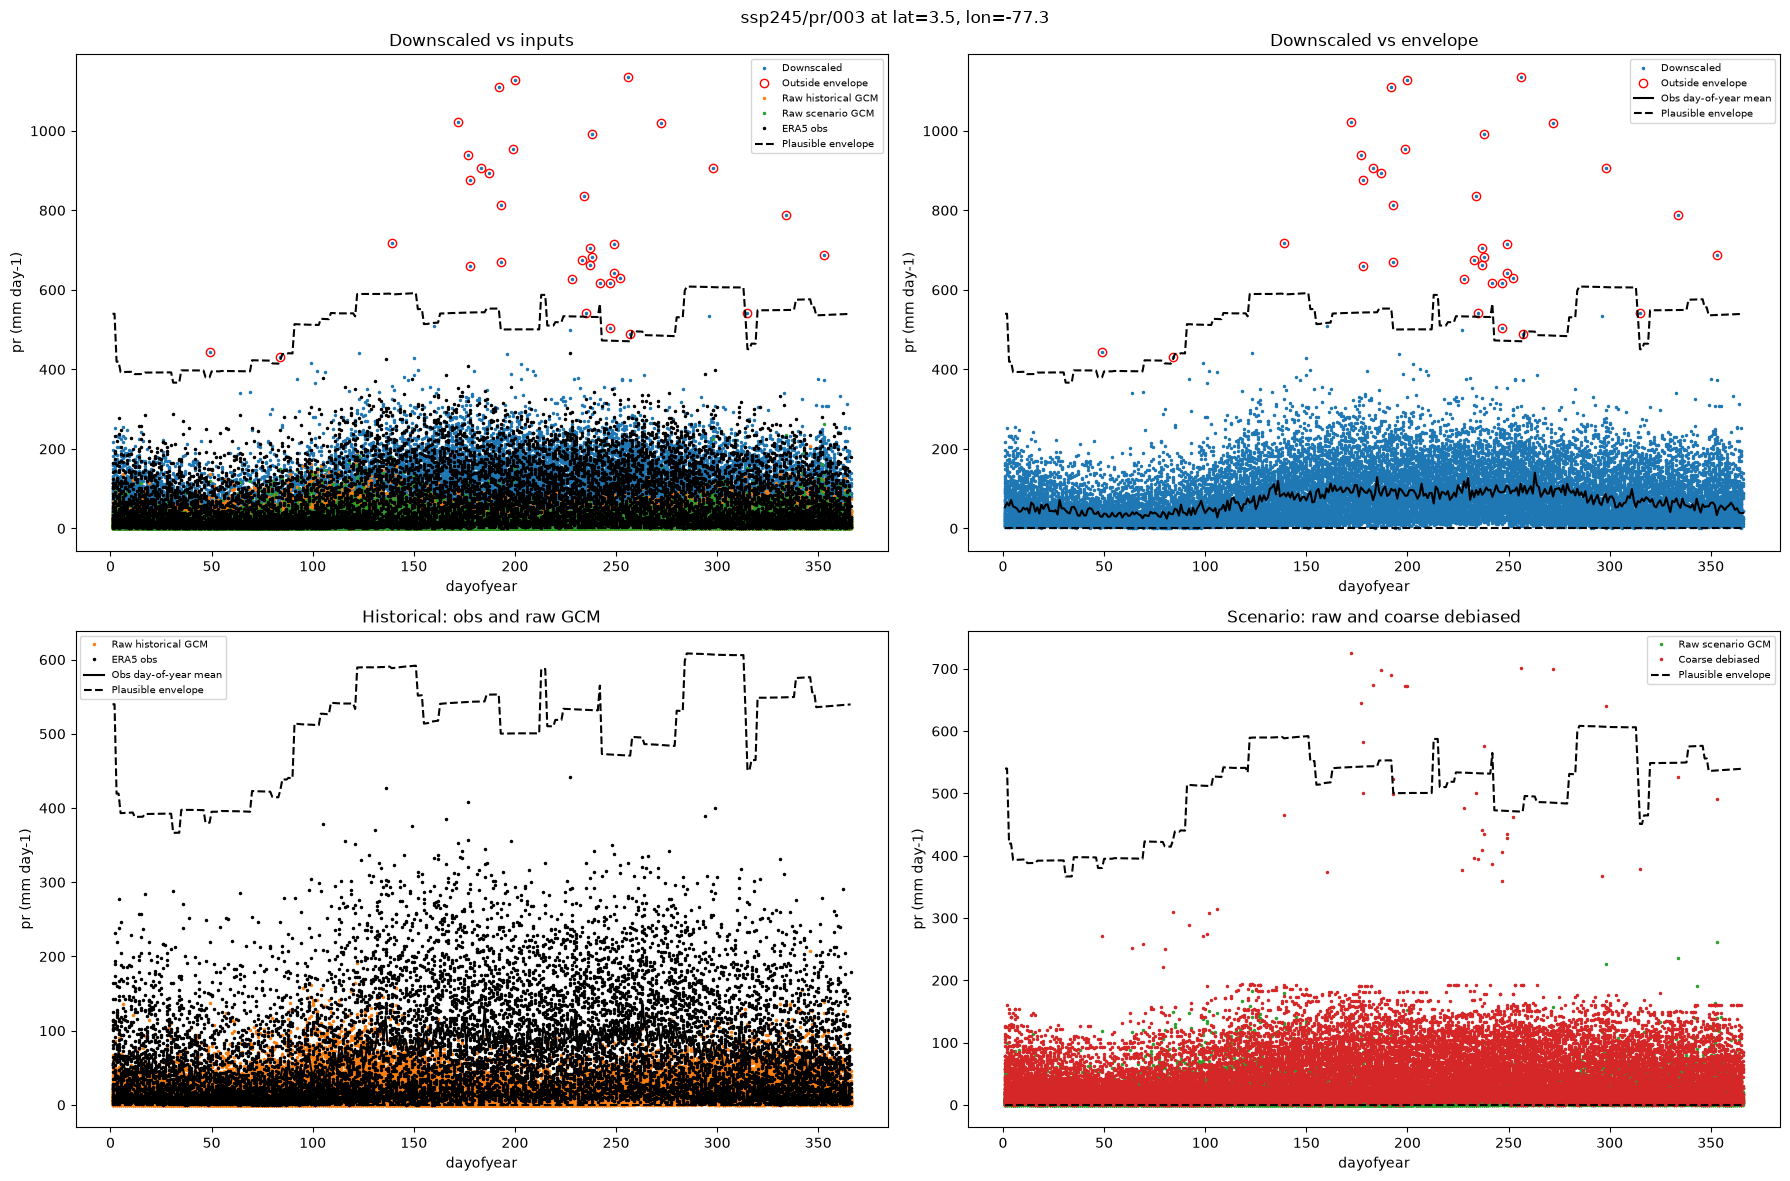

Flagged days at this point: 35 of 31046


In [19]:
n_flagged = plot_point_panels(
    drill_series, drill_key, ilat, ilon, units=drill_units, scale=drill_scale
)
print(f"Flagged days at this point: {n_flagged} of {drill_series['downscaled'].sizes['time']}")

## Summary

Each leaf reports the fraction of the domain that ever leaves its per-day-of-year plausible
envelope, in each direction, together with the largest exceedance and a pass flag at the 2 %
threshold. Because the envelope is intentionally wide and day-of-year specific, a passing leaf is
strong evidence that the downscaling did not invent locally impossible values, while a flagged leaf
points to specific cells and days to inspect with the drill-down rather than to an automatic failure.

On the `v0.13.0` store this covers 32 leaves across six variables and the `historical`, `ssp245` and
`g6_1p5k` groups. Twenty pass and twelve are flagged:

| Variable | Leaves | Flagged | Worst flagged area |
| --- | --- | --- | --- |
| `tas` | 6 | 0 | 0.31 % high |
| `tasmax` | 4 | 0 | 0.42 % high |
| `tasmin` | 4 | 3 | 4.51 % low |
| `pr` | 6 | 0 | 1.59 % high |
| `rsds` | 6 | 6 | 19.06 % high |
| `hurs` | 6 | 3 | 3.16 % high |

`tas`, `tasmax` and `pr` pass everywhere. For `pr` the lower bound barely registers, catching at most
0.003 % of the domain, because the observed day-of-year minimum is itself zero nearly everywhere.
Passing an area test does not make those cells uninteresting: the worst upper-bound exceedance is
861 mm day⁻¹ in `historical/pr/r3i1p1f1`, then 697 and 678 mm day⁻¹ for the two `ssp245` members.

Three of the four `tasmin` leaves cross the threshold, all on the low side and all in the scenarios
rather than the historical period: `ssp245/008` at 3.97 %, `g6_1p5k/002` at 4.35 % and
`g6_1p5k/003` at 4.51 %. `historical/tasmin/001` passes at 0.19 %.

Every `rsds` leaf crosses the threshold by a wide margin and does so consistently, roughly 19 % of
the domain too high and 3.5 % too low in all six, which is the signature of a systematic offset
rather than a scenario-specific one. The largest upper-bound exceedance is 148 W m⁻²
(`ssp245/rsds/003`); the drill-down above inspects that leaf. `hurs` is flagged on the three scenario
leaves it covers, between 1.8 % and 3.2 % too high, and passes historically.

`hurs` is new to this check. Earlier revisions ran five variables and left it out, so those leaves
had no location- and season-aware bound on them at all.

In [20]:
if cluster is not None:
    cluster.shutdown()
else:
    print("no cluster was created (cached run); nothing to shut down")